In [128]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [129]:
credit = pd.read_csv('data/credit_data_risk.csv')

In [130]:
credit.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [131]:
del credit['Unnamed: 0']

In [132]:
credit.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [133]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
plt.rcParams["figure.figsize"] = (10,6)

In [134]:
numerical_credit = credit.select_dtypes(exclude='O')

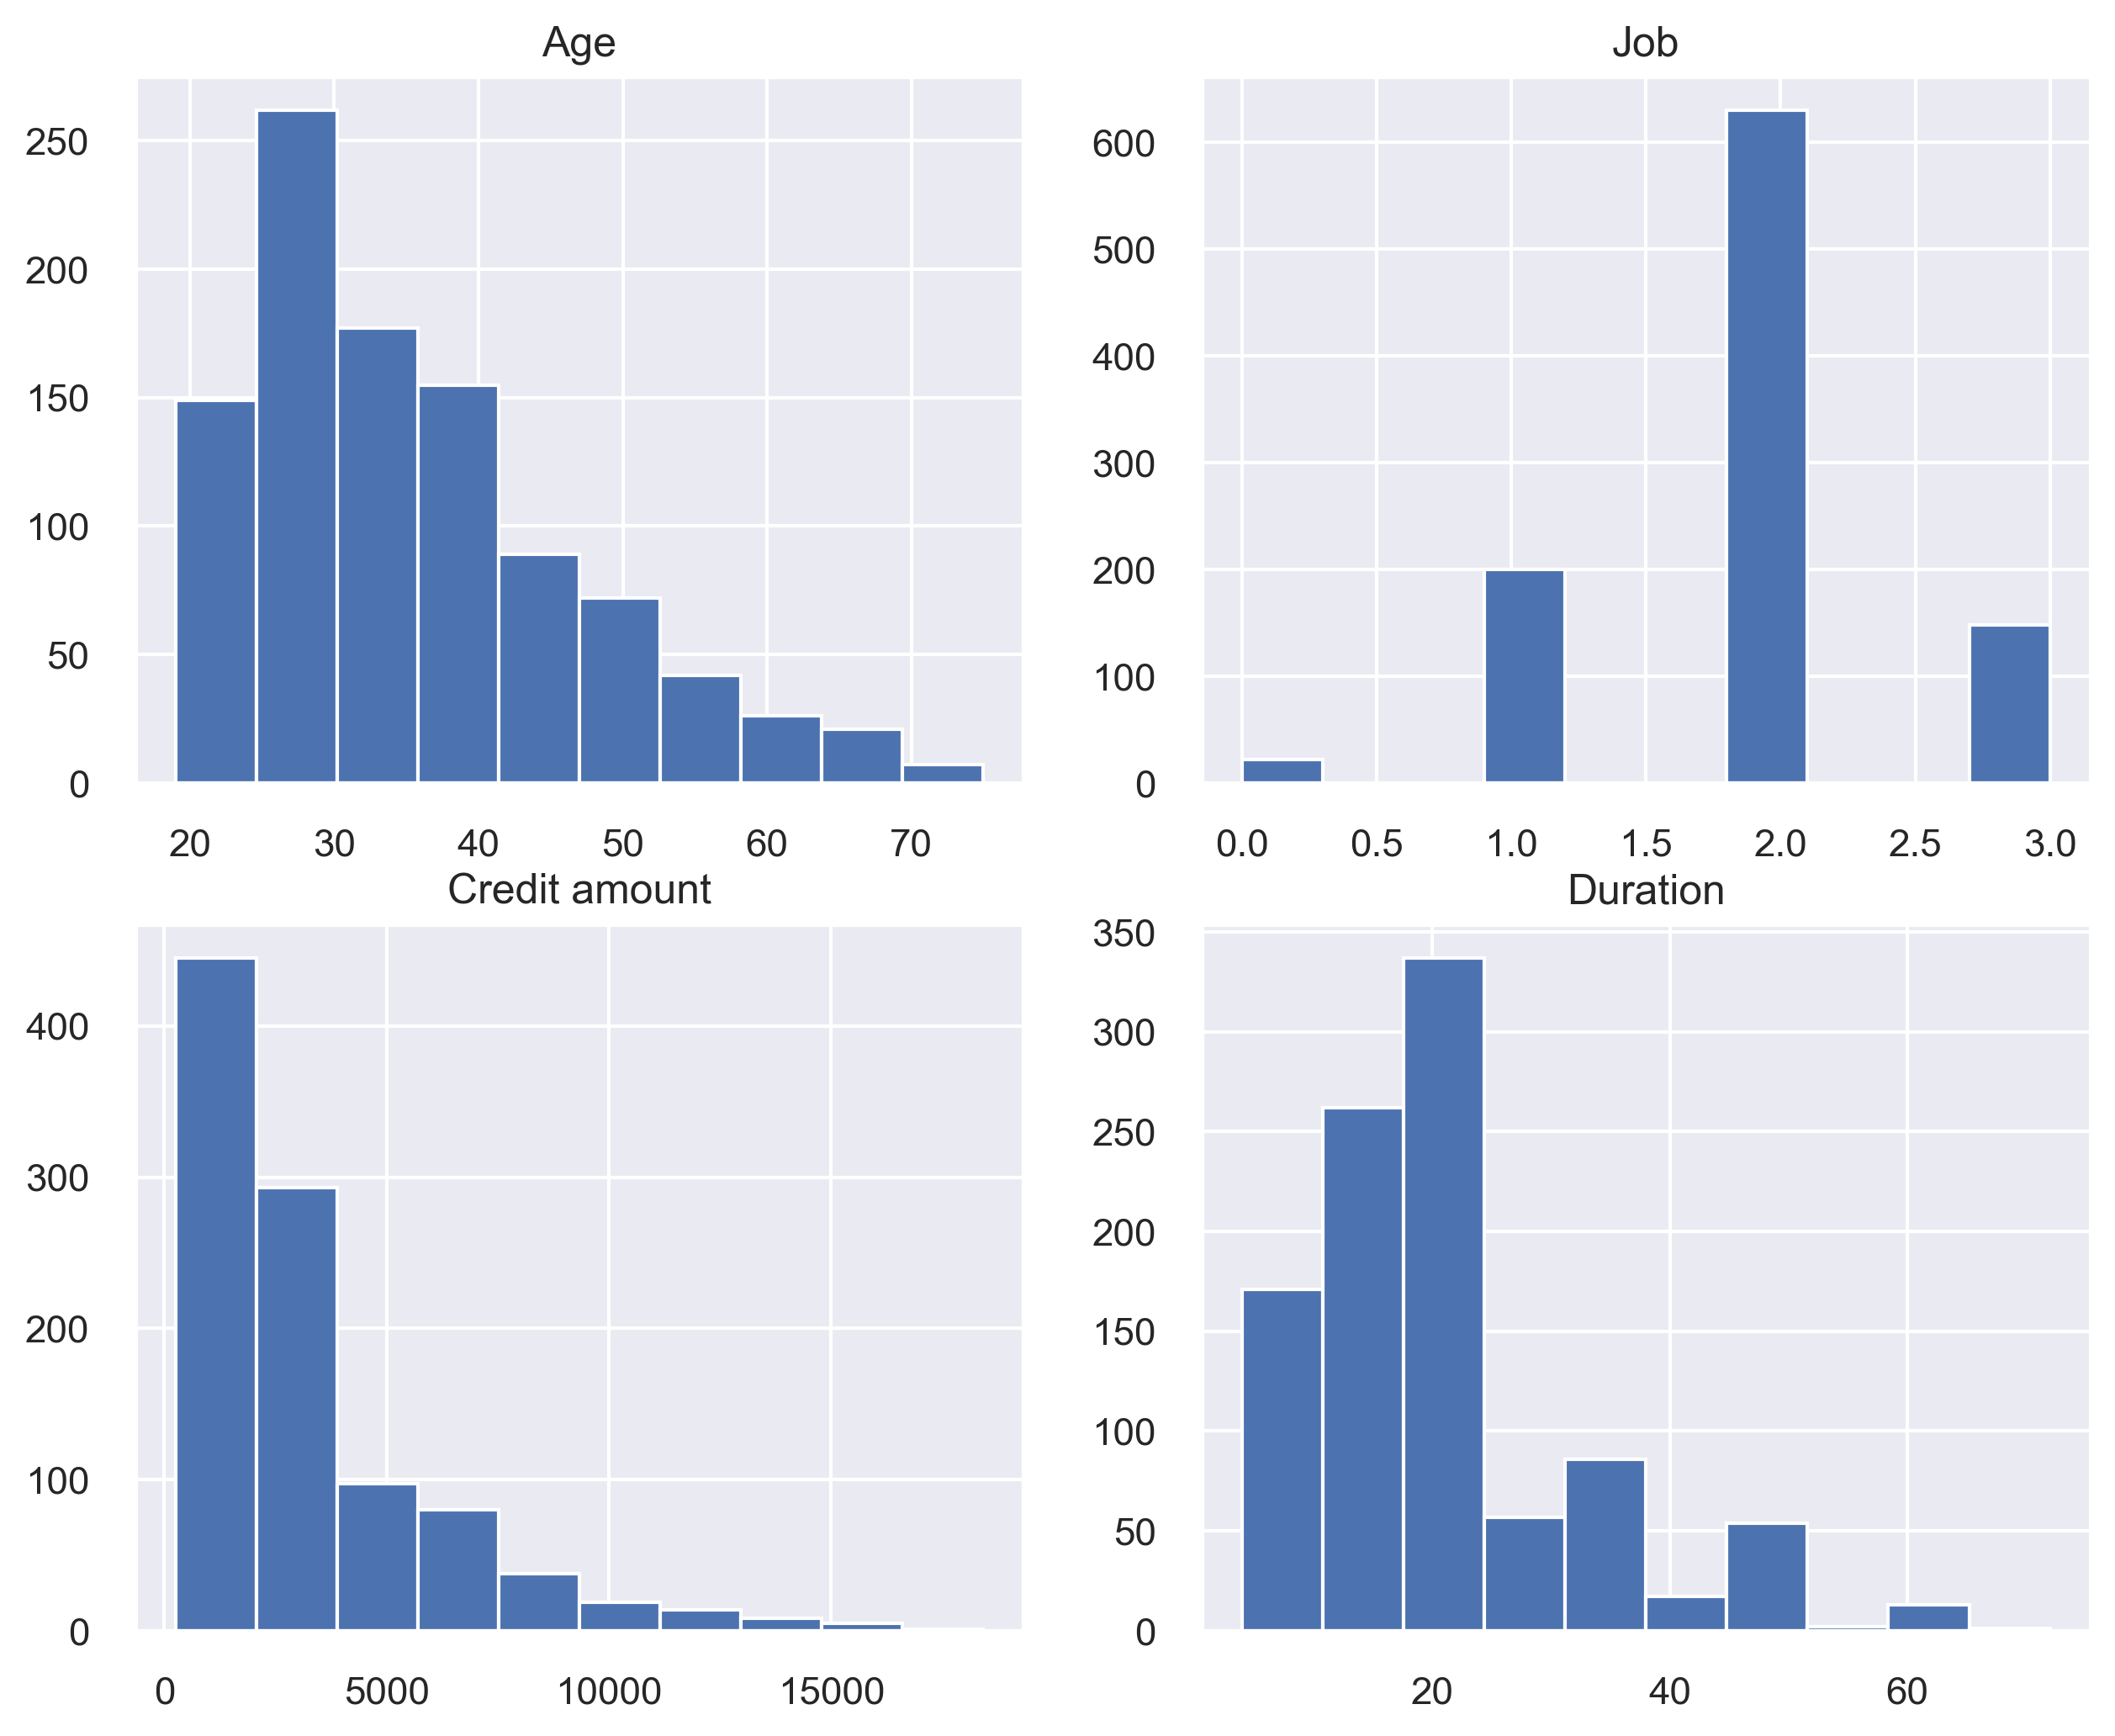

In [135]:
plt.figure(figsize=(10, 8))
k = 0
cols = numerical_credit.columns
for i, j in zip(range(len(cols)), cols):
    k +=1
    plt.subplot(2, 2, k)
    plt.hist(numerical_credit.iloc[:, i])
    plt.title(j)

In [136]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

In [137]:
scaler = StandardScaler()
scaled_credit = scaler.fit_transform(numerical_credit)

In [138]:
distance = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled_credit)
    distance.append(kmeans.inertia_)

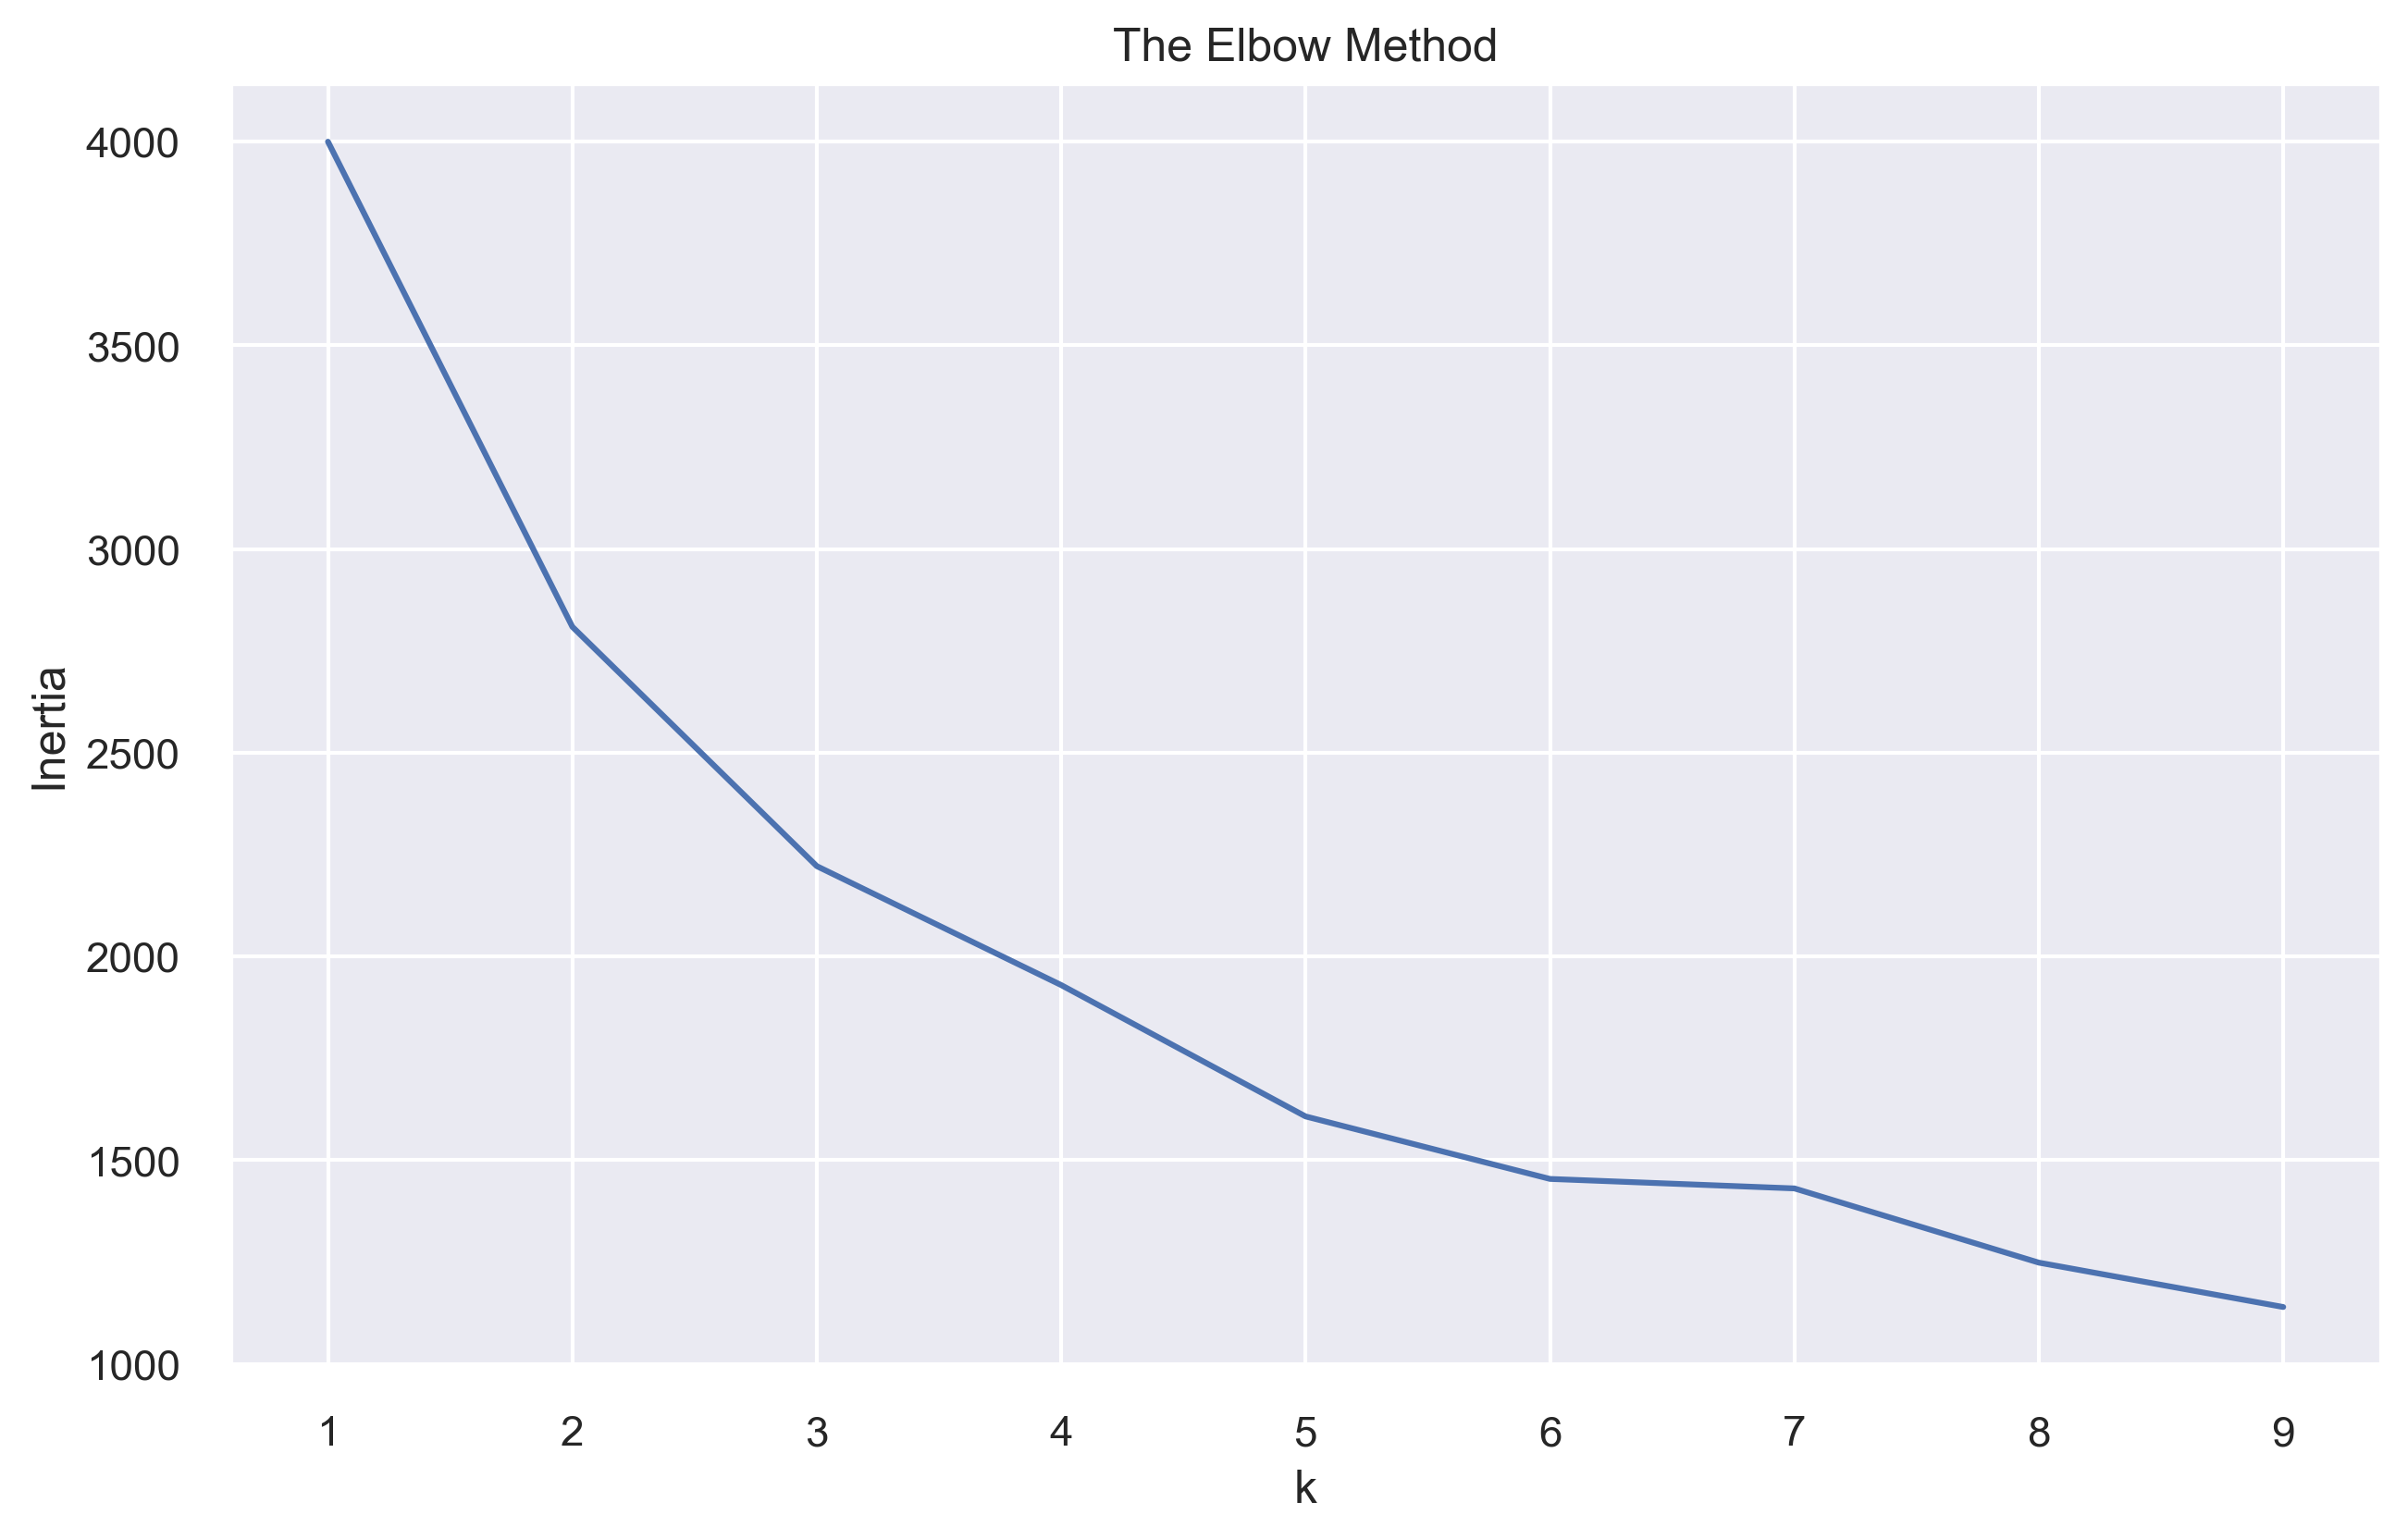

In [139]:
plt.plot(range(1, 10), distance, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('The Elbow Method')
plt.show()

In [140]:
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

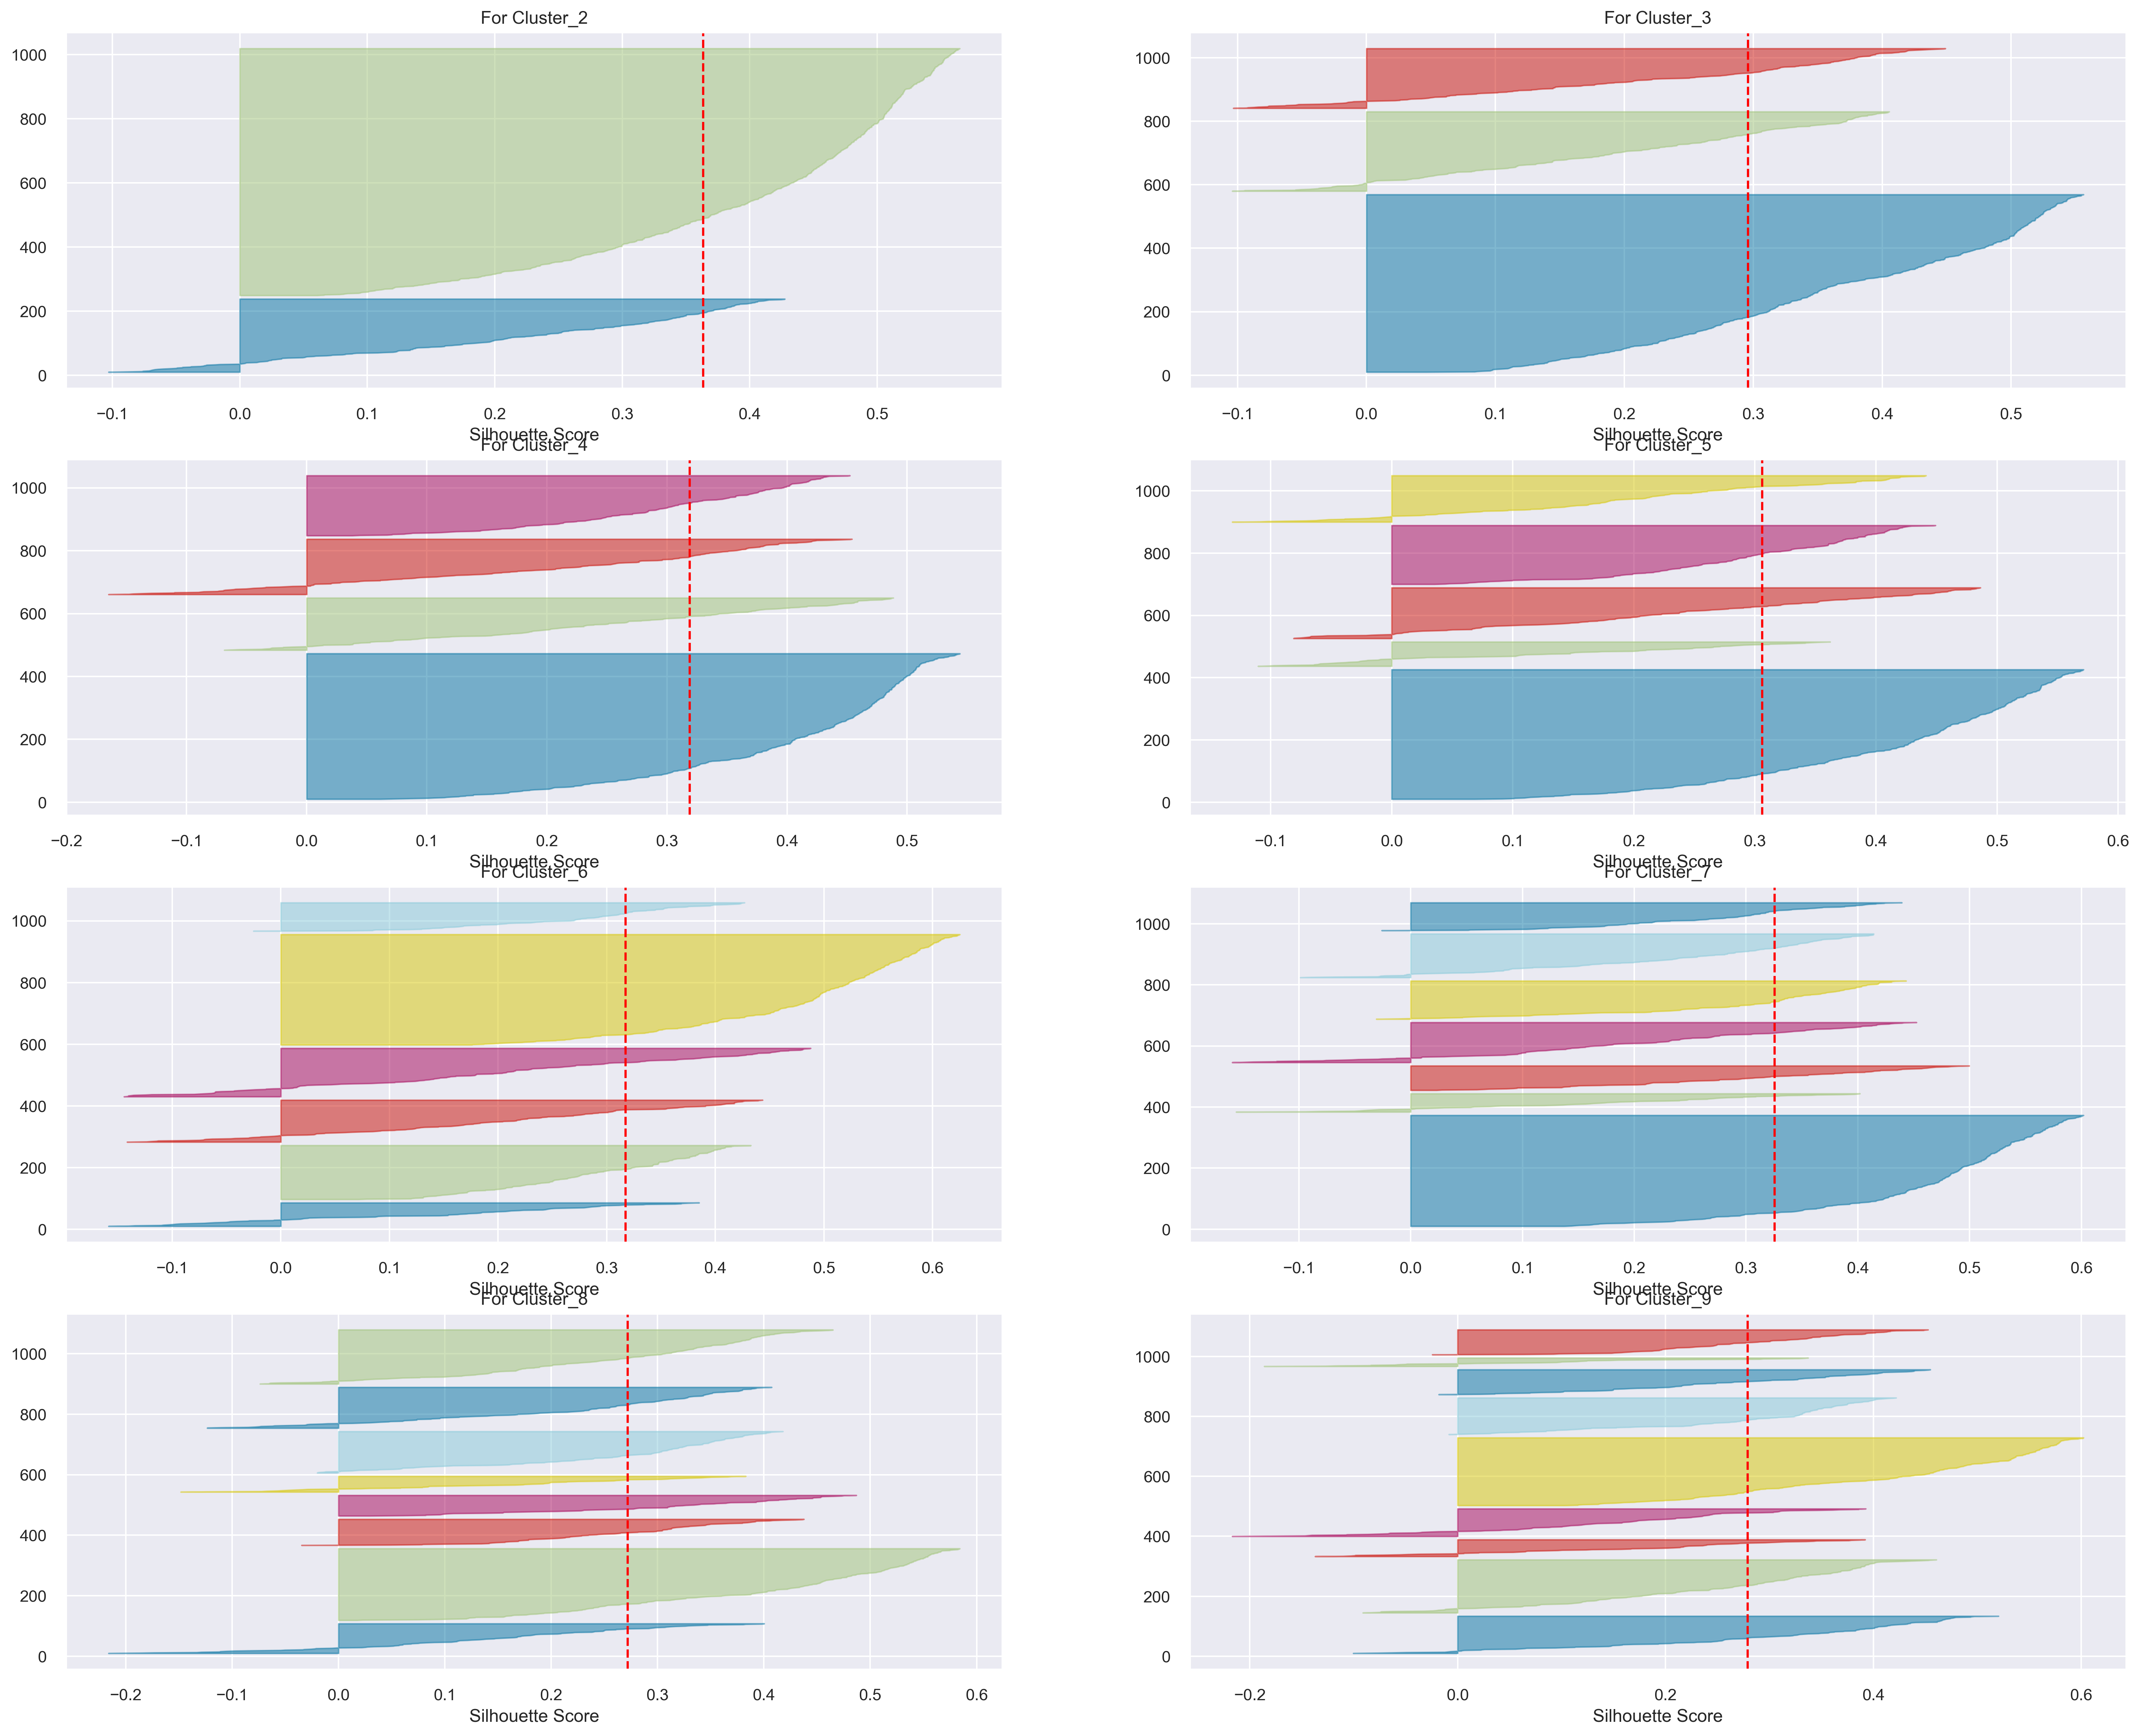

In [141]:
fig, ax = plt.subplots(4, 2, figsize=(25, 20))
for i in range(2, 10):
    km = KMeans(n_clusters=i)
    q, r = divmod(i, 2)
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick',
                                      ax=ax[q - 1][r])
    visualizer.fit(scaled_credit)
    ax[q - 1][r].set_title("For Cluster_"+str(i))
    ax[q - 1][r].set_xlabel("Silhouette Score")

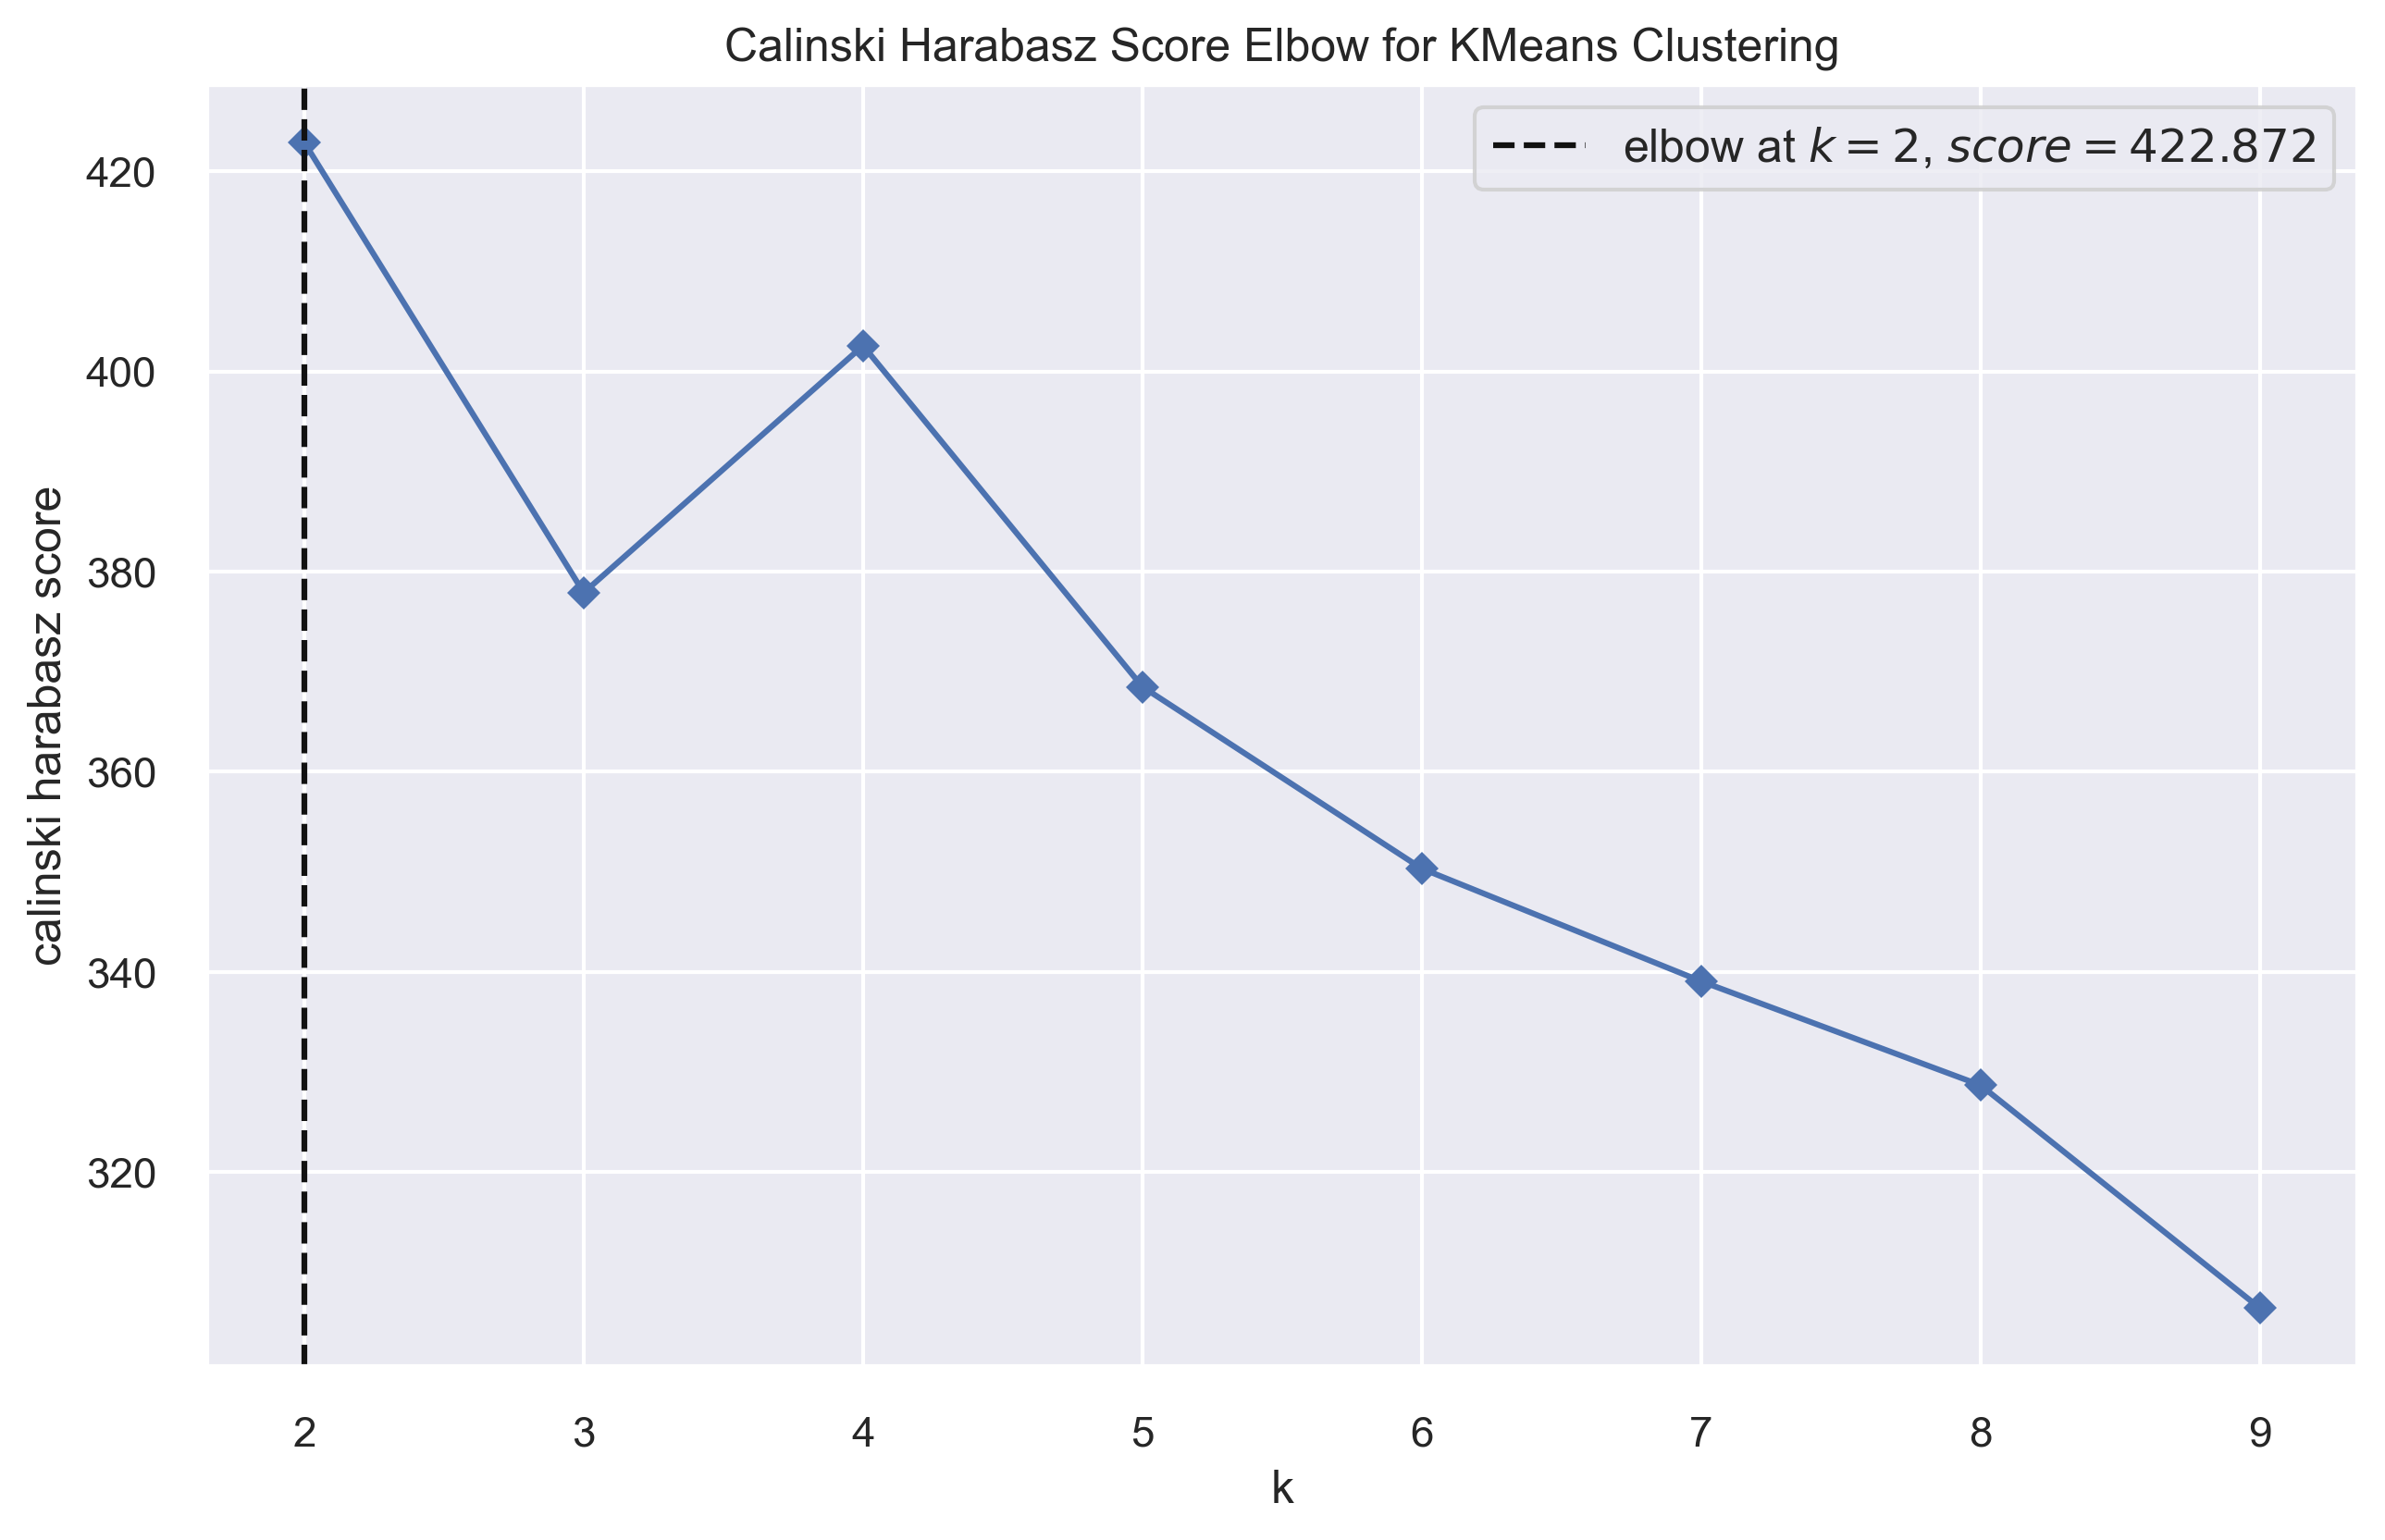

In [142]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2, 10),
                              metric='calinski_harabasz',
                              timings=False)
visualizer.fit(scaled_credit)
visualizer.show();

In [143]:
kmeans = KMeans(n_clusters=4)
clusters = kmeans.fit_predict(scaled_credit)

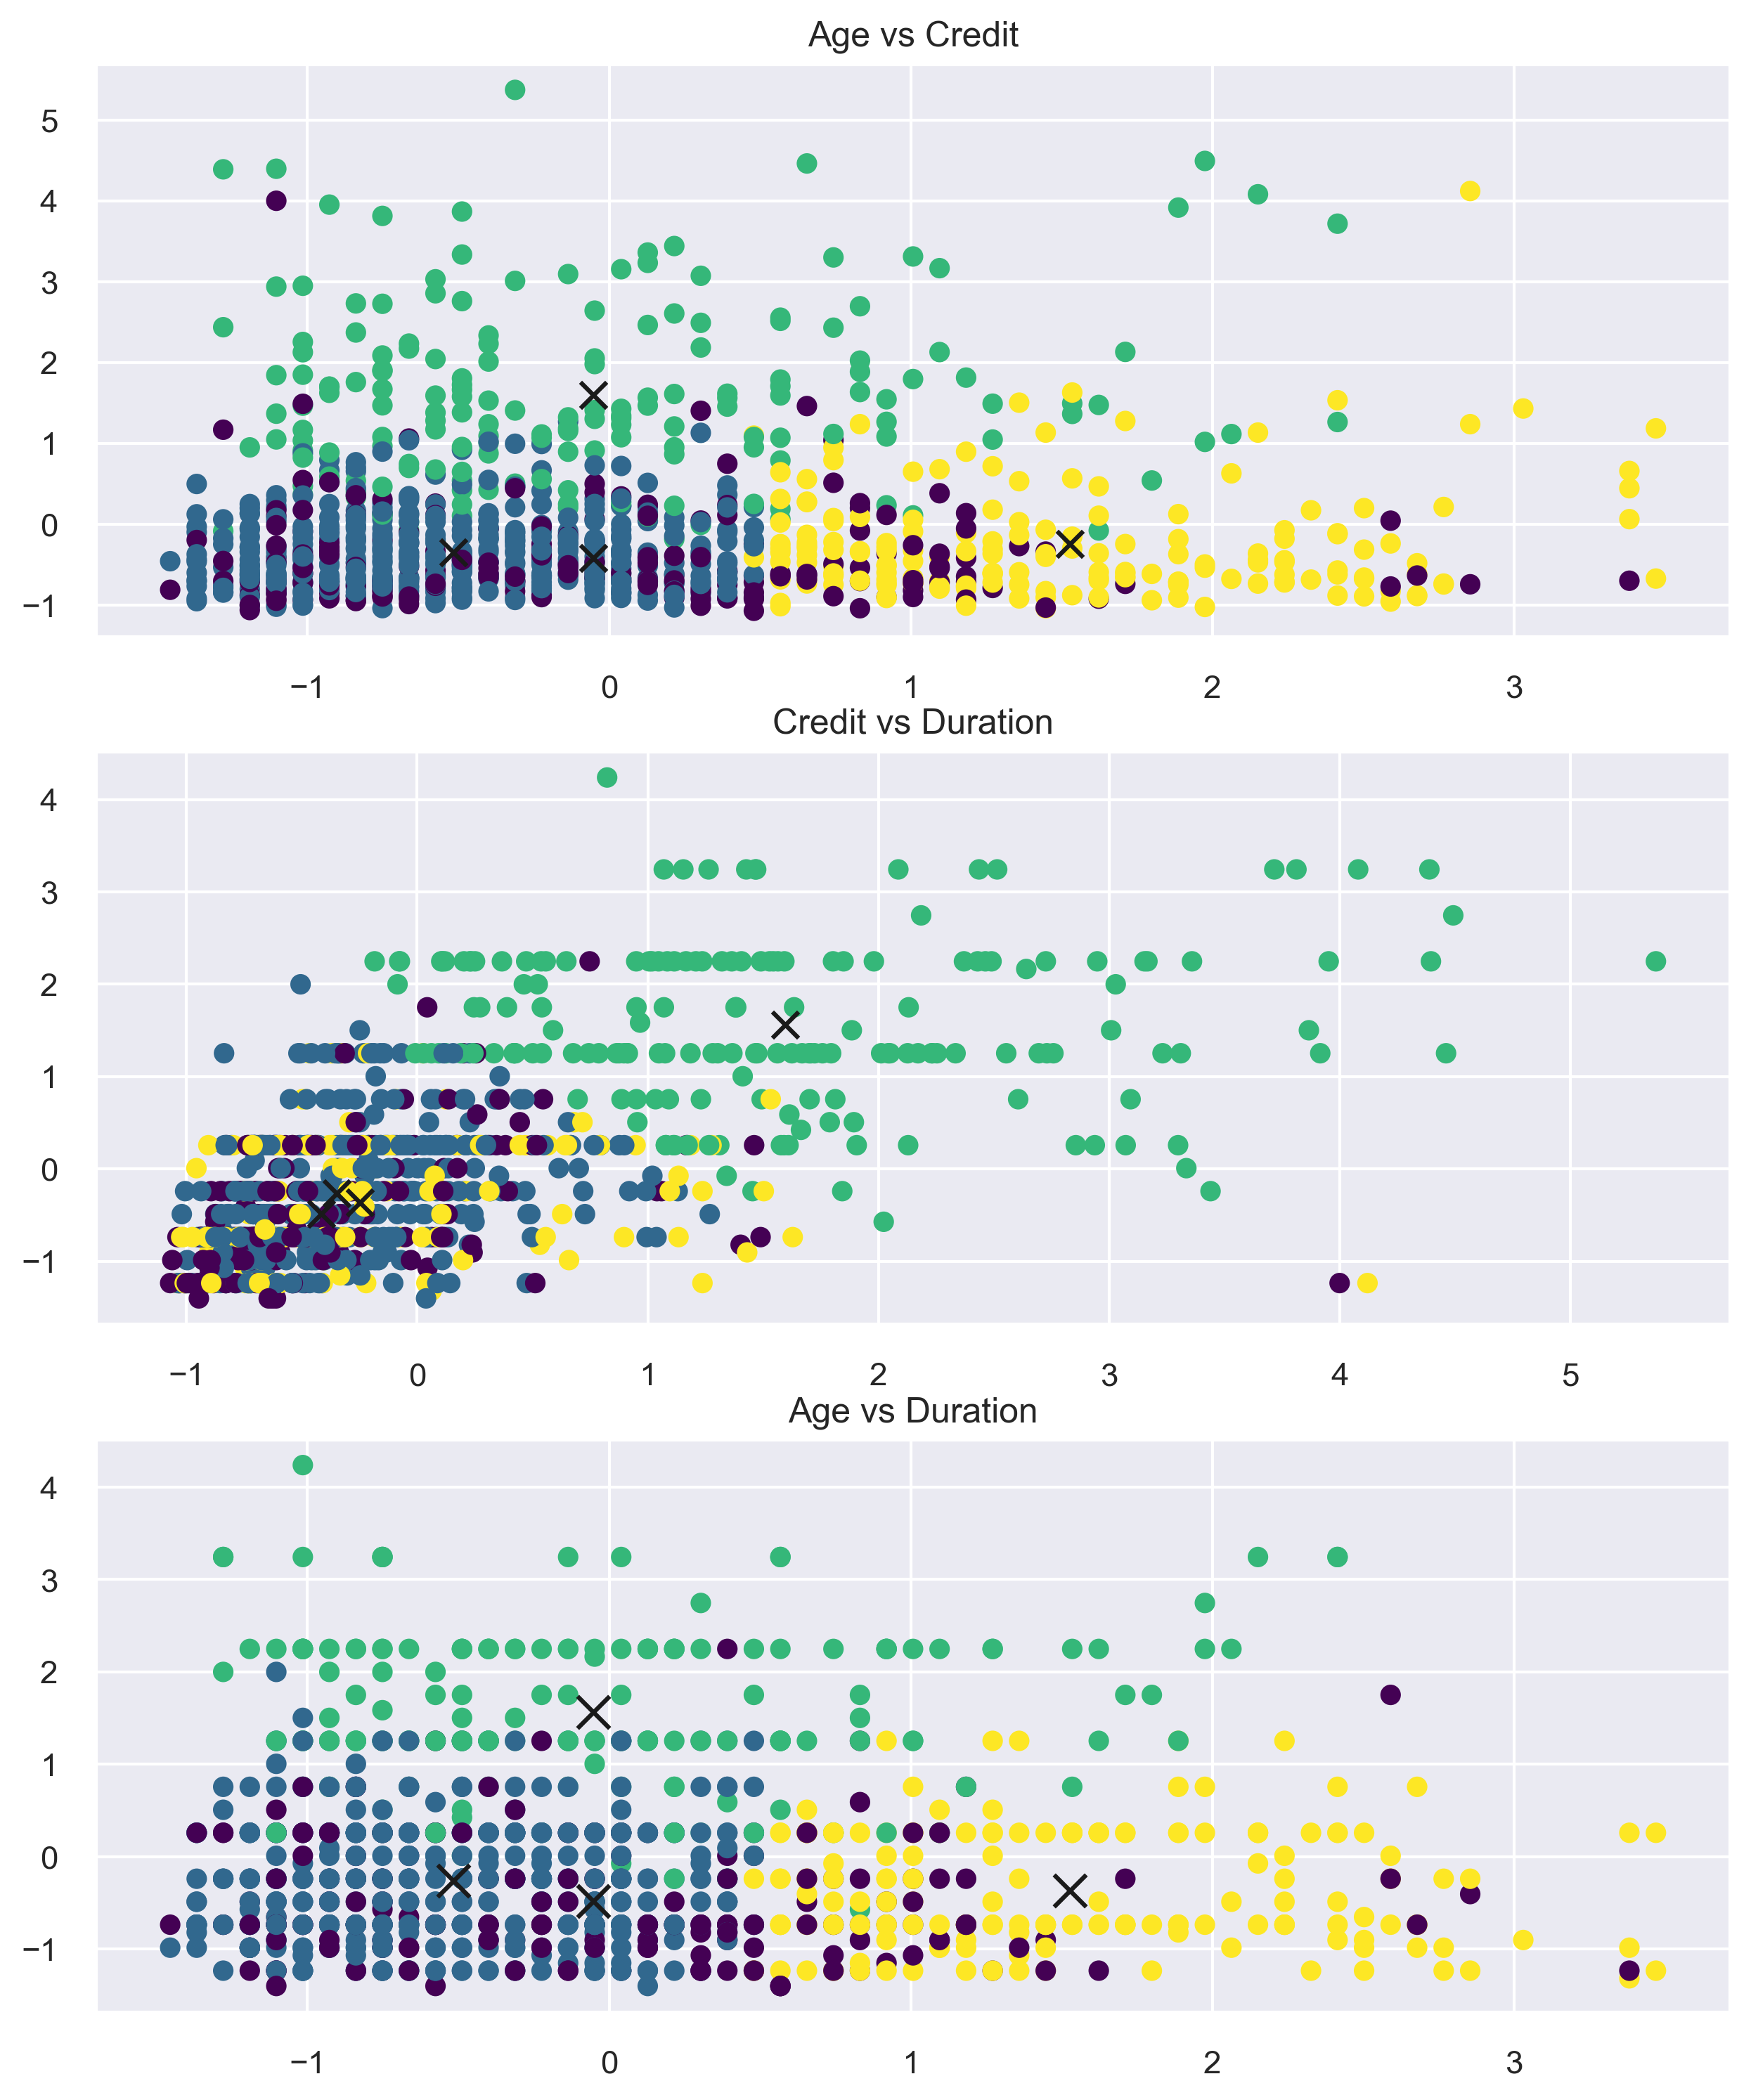

In [144]:
plt.figure(figsize=(10, 12))
plt.subplot(311)
plt.scatter(scaled_credit[:, 0], scaled_credit[:, 2],
            c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 2], s = 80,
            marker= 'x', color = 'k')
plt.title('Age vs Credit')
plt.subplot(312)
plt.scatter(scaled_credit[:, 2], scaled_credit[:, 3],
            c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 2],
            kmeans.cluster_centers_[:, 3], s = 80,
            marker= 'x', color = 'k')
plt.title('Credit vs Duration')
plt.subplot(313)
plt.scatter(scaled_credit[:, 0], scaled_credit[:, 3],
            c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 3], s = 120,
            marker= 'x', color = 'k')
plt.title('Age vs Duration')
plt.show()

In [145]:
clusters, counts = np.unique(kmeans.labels_, return_counts=True)
clusters, counts

(array([0, 1, 2, 3], dtype=int32), array([193, 461, 177, 169]))

In [146]:
cluster_dict = {}
for i in range(len(clusters)):
    cluster_dict[i] = scaled_credit[np.where(kmeans.labels_==i)]



In [147]:
df_scaled = pd.DataFrame(scaled_credit)
df_scaled['clusters'] = pd.DataFrame(kmeans.labels_)
df_scaled.head()

,0,1,2,3,clusters
0,2.766456,0.146949,-0.745131,-1.236478,3
1,-1.191404,0.146949,0.949817,2.248194,2
2,1.183312,-1.383771,-0.416562,-0.738668,0
3,0.831502,0.146949,1.634247,1.750384,2
4,1.535122,0.146949,0.566664,0.256953,3


In [148]:
df_scaled['Risk'] = credit['Risk']
df_scaled.columns = ['Age', 'Job', 'Credit amount',
                     'Duration', 'Clusters', 'Risk']

In [149]:
df_scaled.head()

,Age,Job,Credit amount,Duration,Clusters,Risk
0,2.766456,0.146949,-0.745131,-1.236478,3,good
1,-1.191404,0.146949,0.949817,2.248194,2,bad
2,1.183312,-1.383771,-0.416562,-0.738668,0,good
3,0.831502,0.146949,1.634247,1.750384,2,good
4,1.535122,0.146949,0.566664,0.256953,3,bad


In [150]:
df_scaled[df_scaled.Clusters == 0]['Risk'].value_counts()

Risk
good    140
bad      53
Name: count, dtype: int64

In [151]:
df_scaled[df_scaled.Clusters == 1]['Risk'].value_counts()

Risk
good    335
bad     126
Name: count, dtype: int64

In [152]:
df_scaled[df_scaled.Clusters == 2]['Risk'].value_counts()

Risk
good    94
bad     83
Name: count, dtype: int64

In [153]:
df_scaled[df_scaled.Clusters == 3]['Risk'].value_counts()

Risk
good    131
bad      38
Name: count, dtype: int64

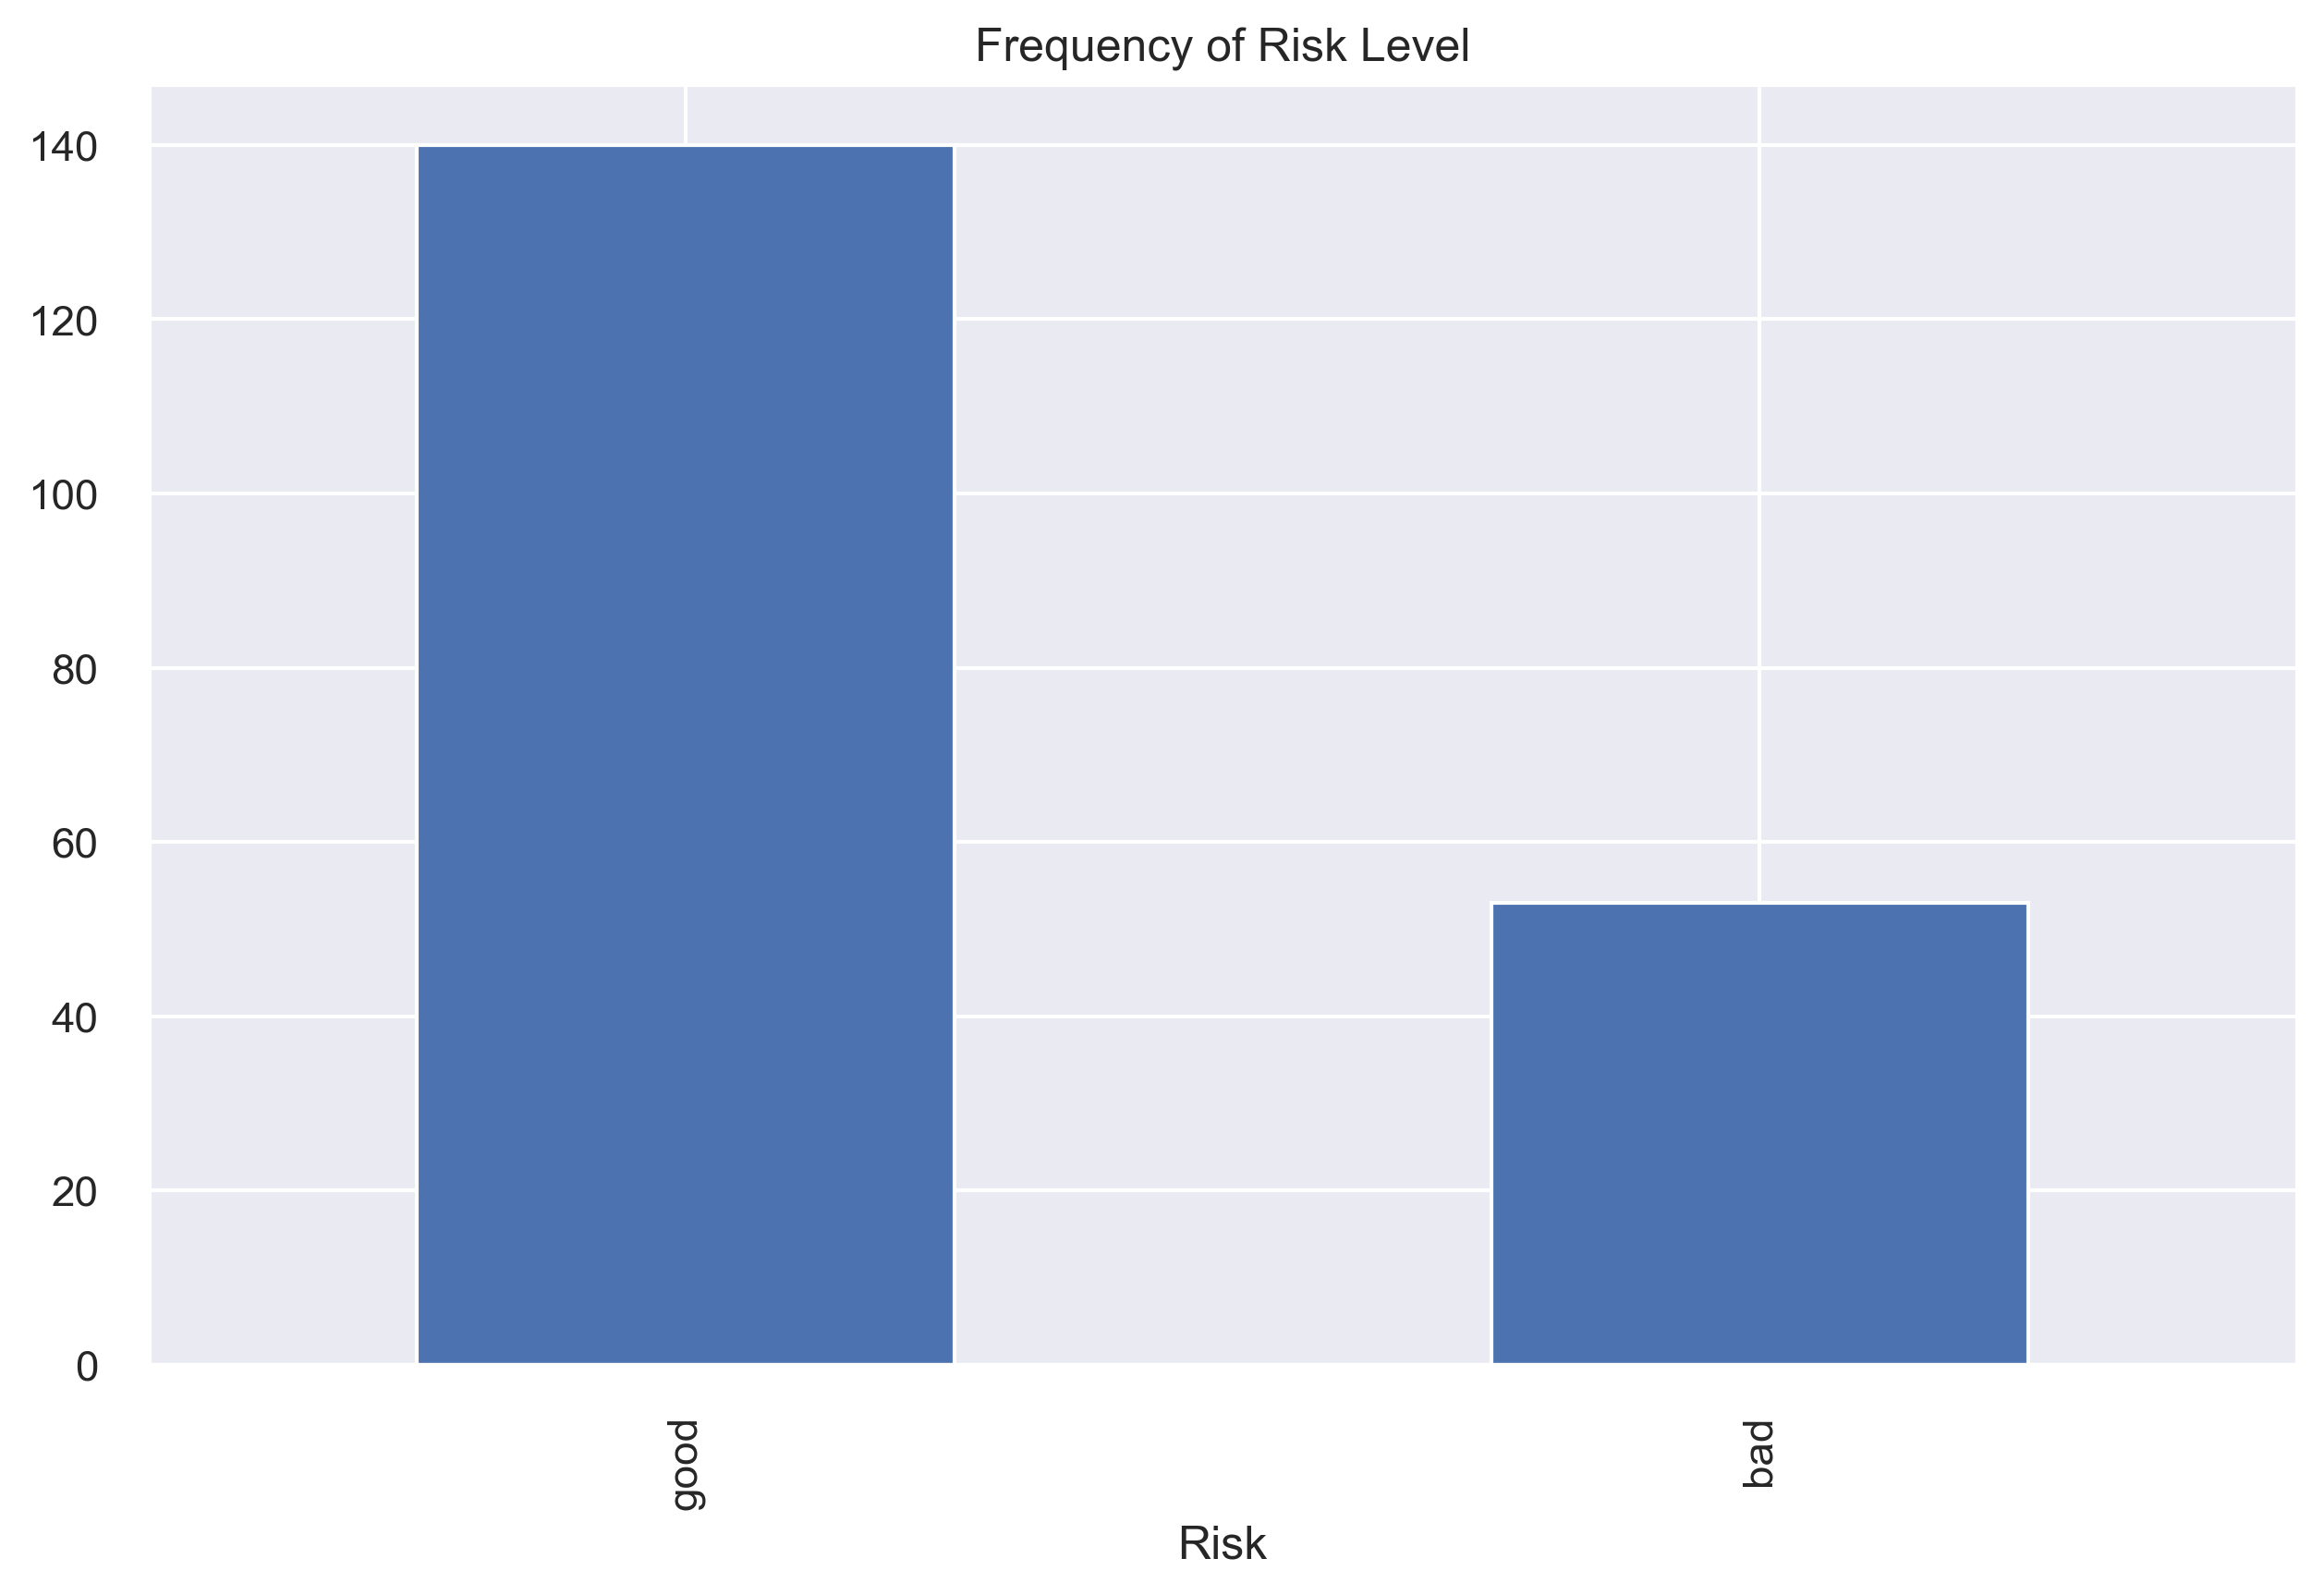

In [154]:
df_scaled[df_scaled.Clusters == 0]['Risk'].value_counts()\
                                    .plot(kind='bar',
                                    figsize=(10, 6),
                                    title="Frequency of Risk Level")
plt.show()

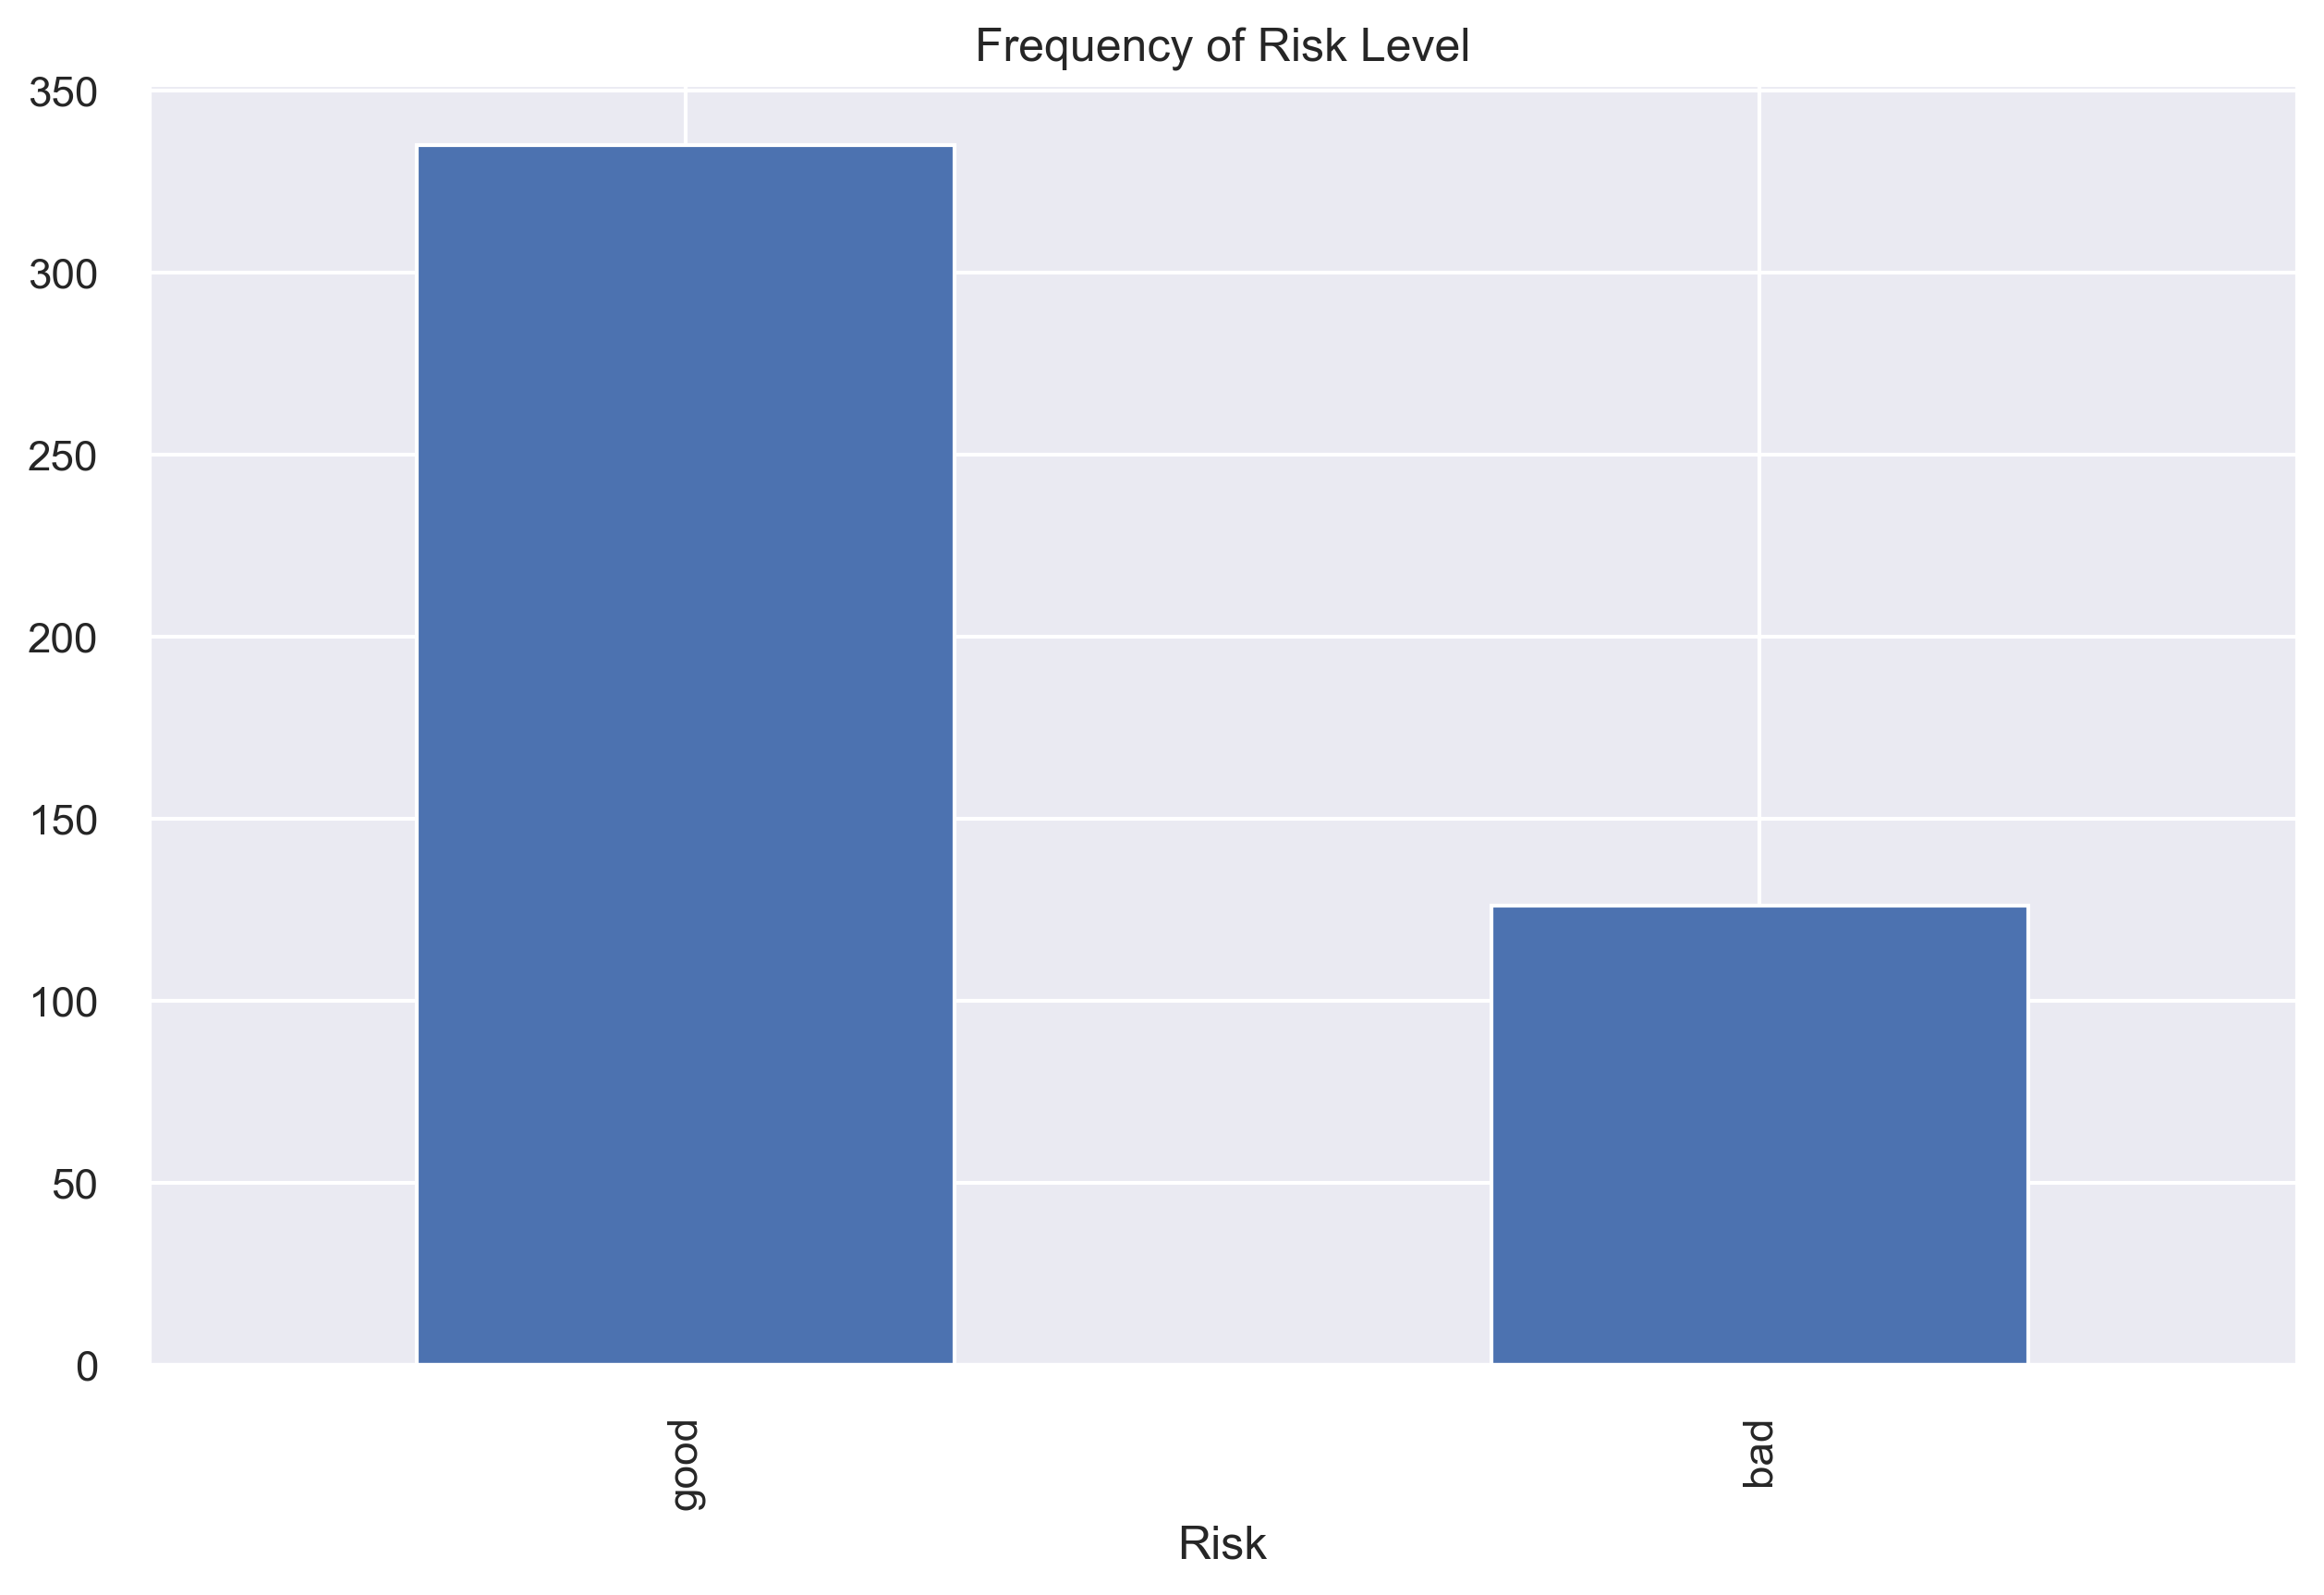

In [155]:
df_scaled[df_scaled.Clusters == 1]['Risk'].value_counts()\
                                    .plot(kind='bar',
                                    figsize=(10, 6),
                                    title="Frequency of Risk Level")
plt.show()

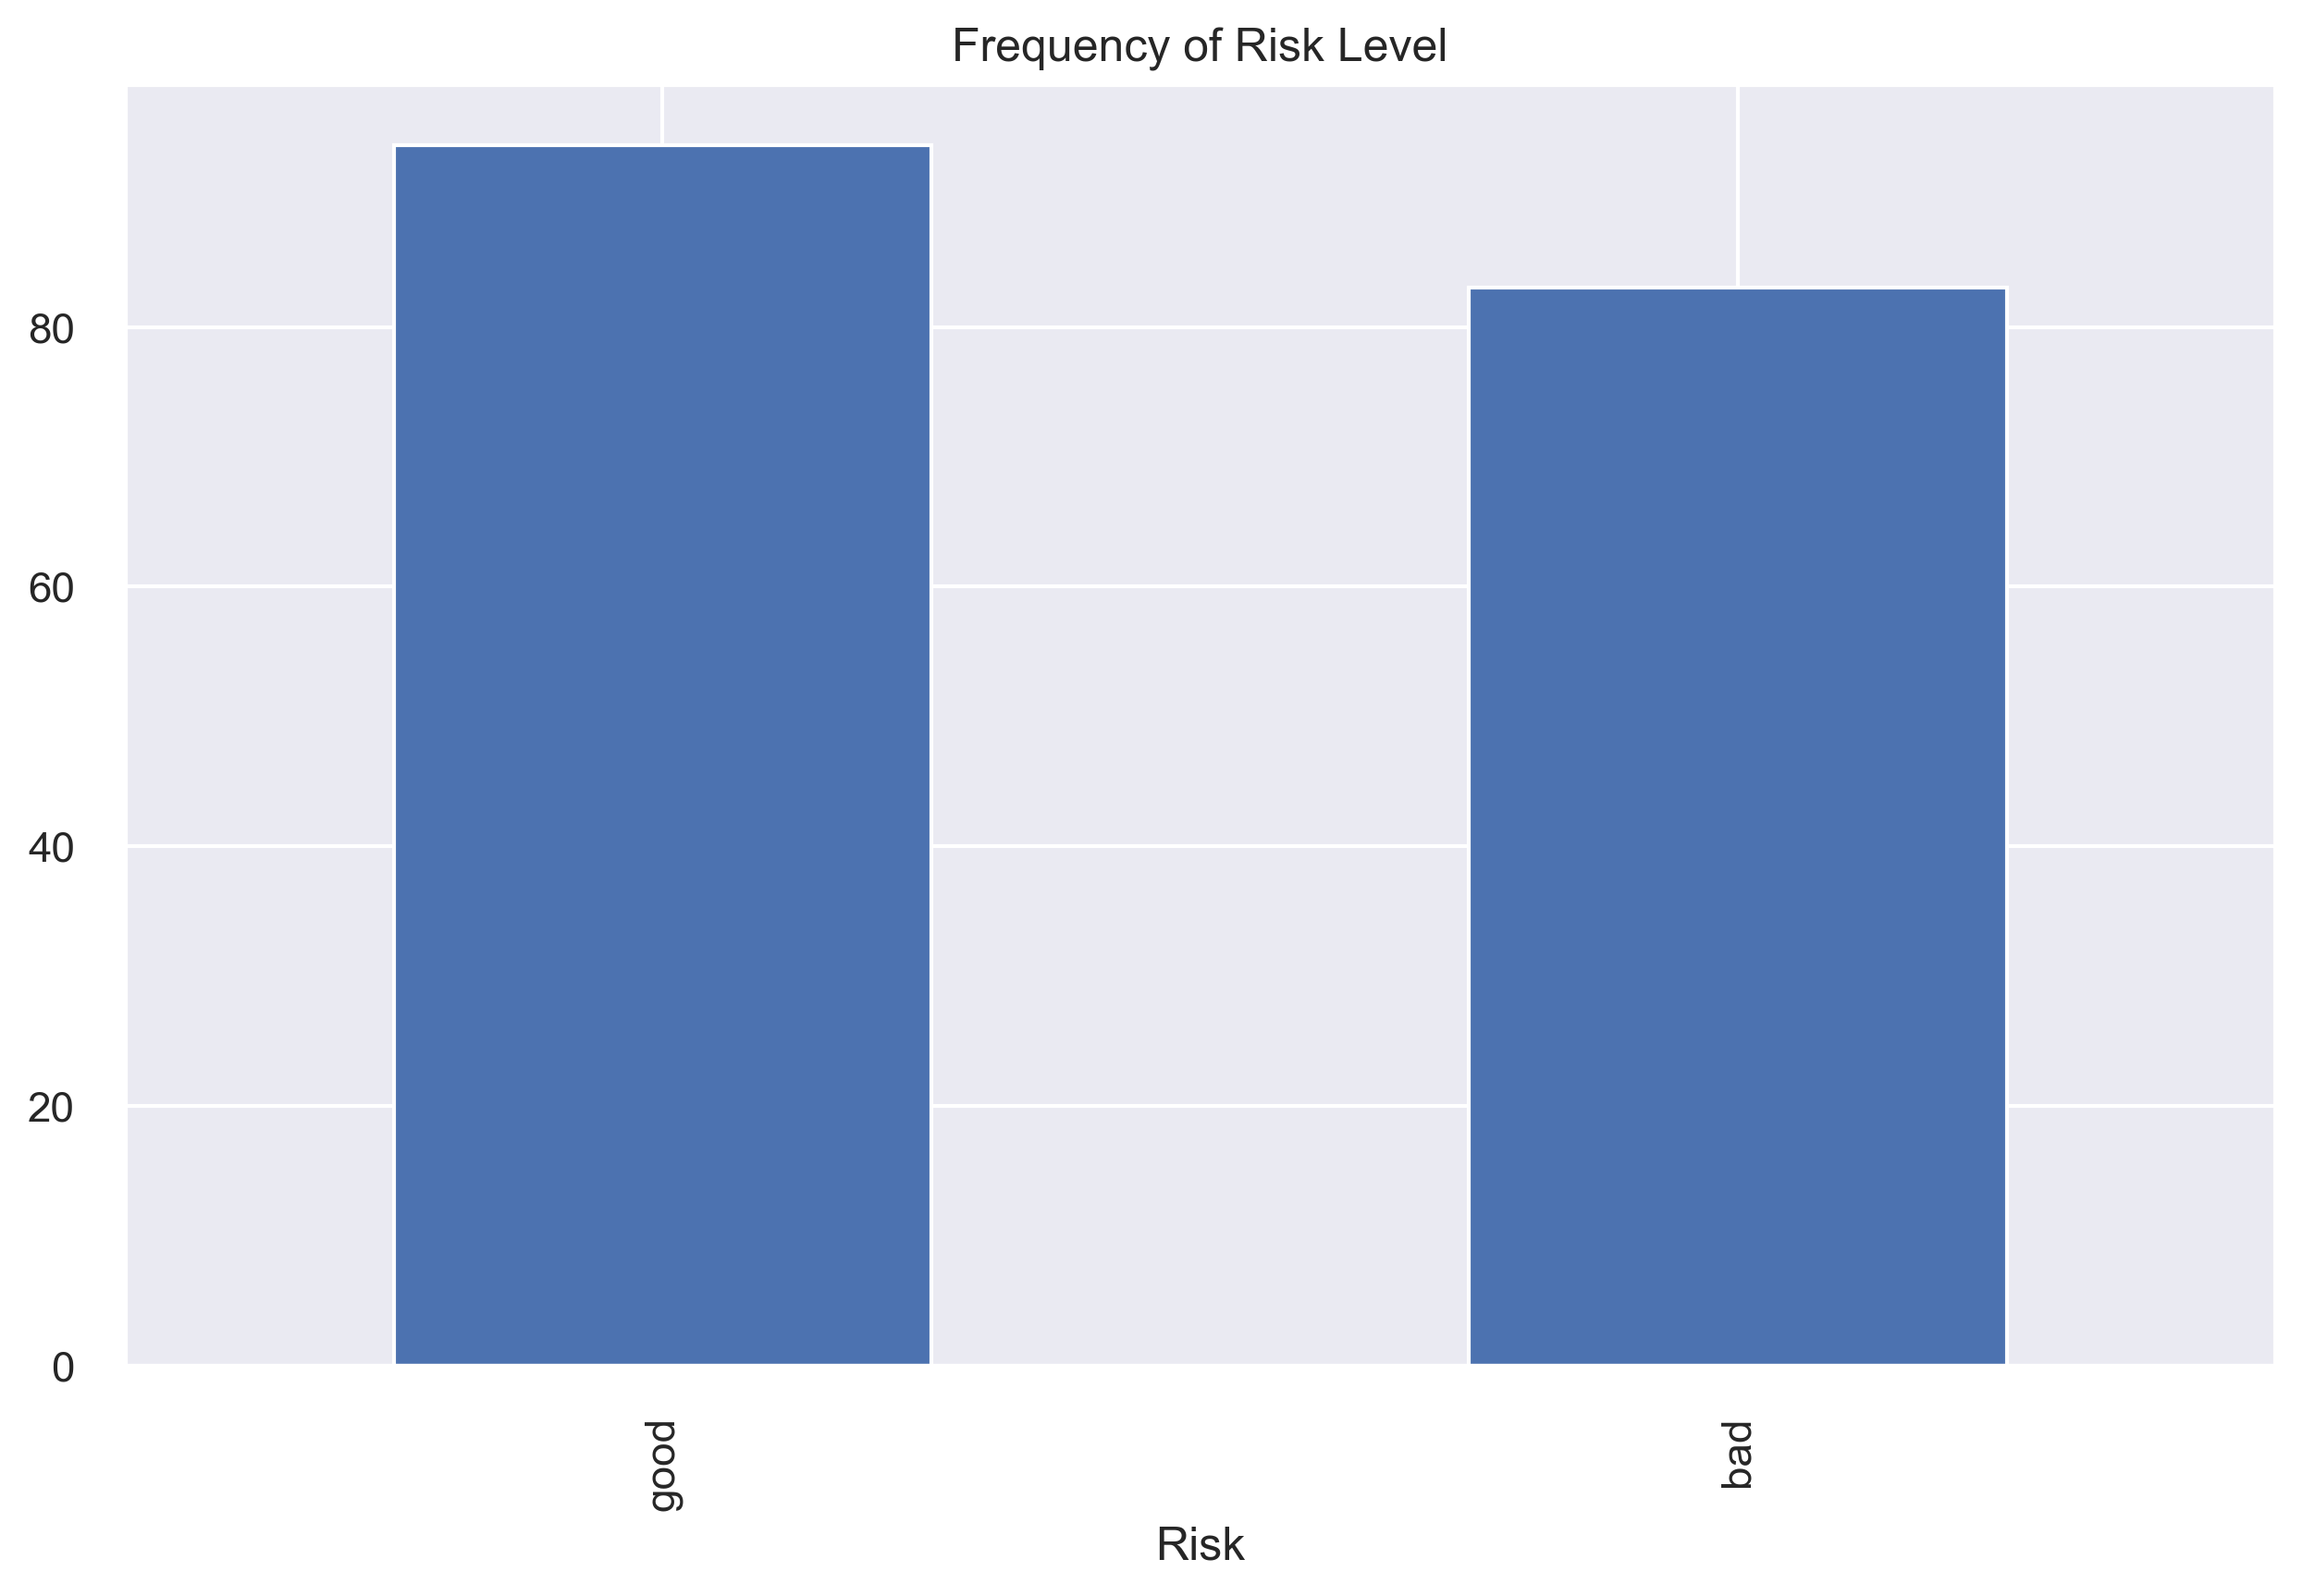

In [156]:
df_scaled[df_scaled.Clusters == 2]['Risk'].value_counts()\
                                    .plot(kind='bar',
                                    figsize=(10, 6),
                                    title="Frequency of Risk Level")
plt.show()

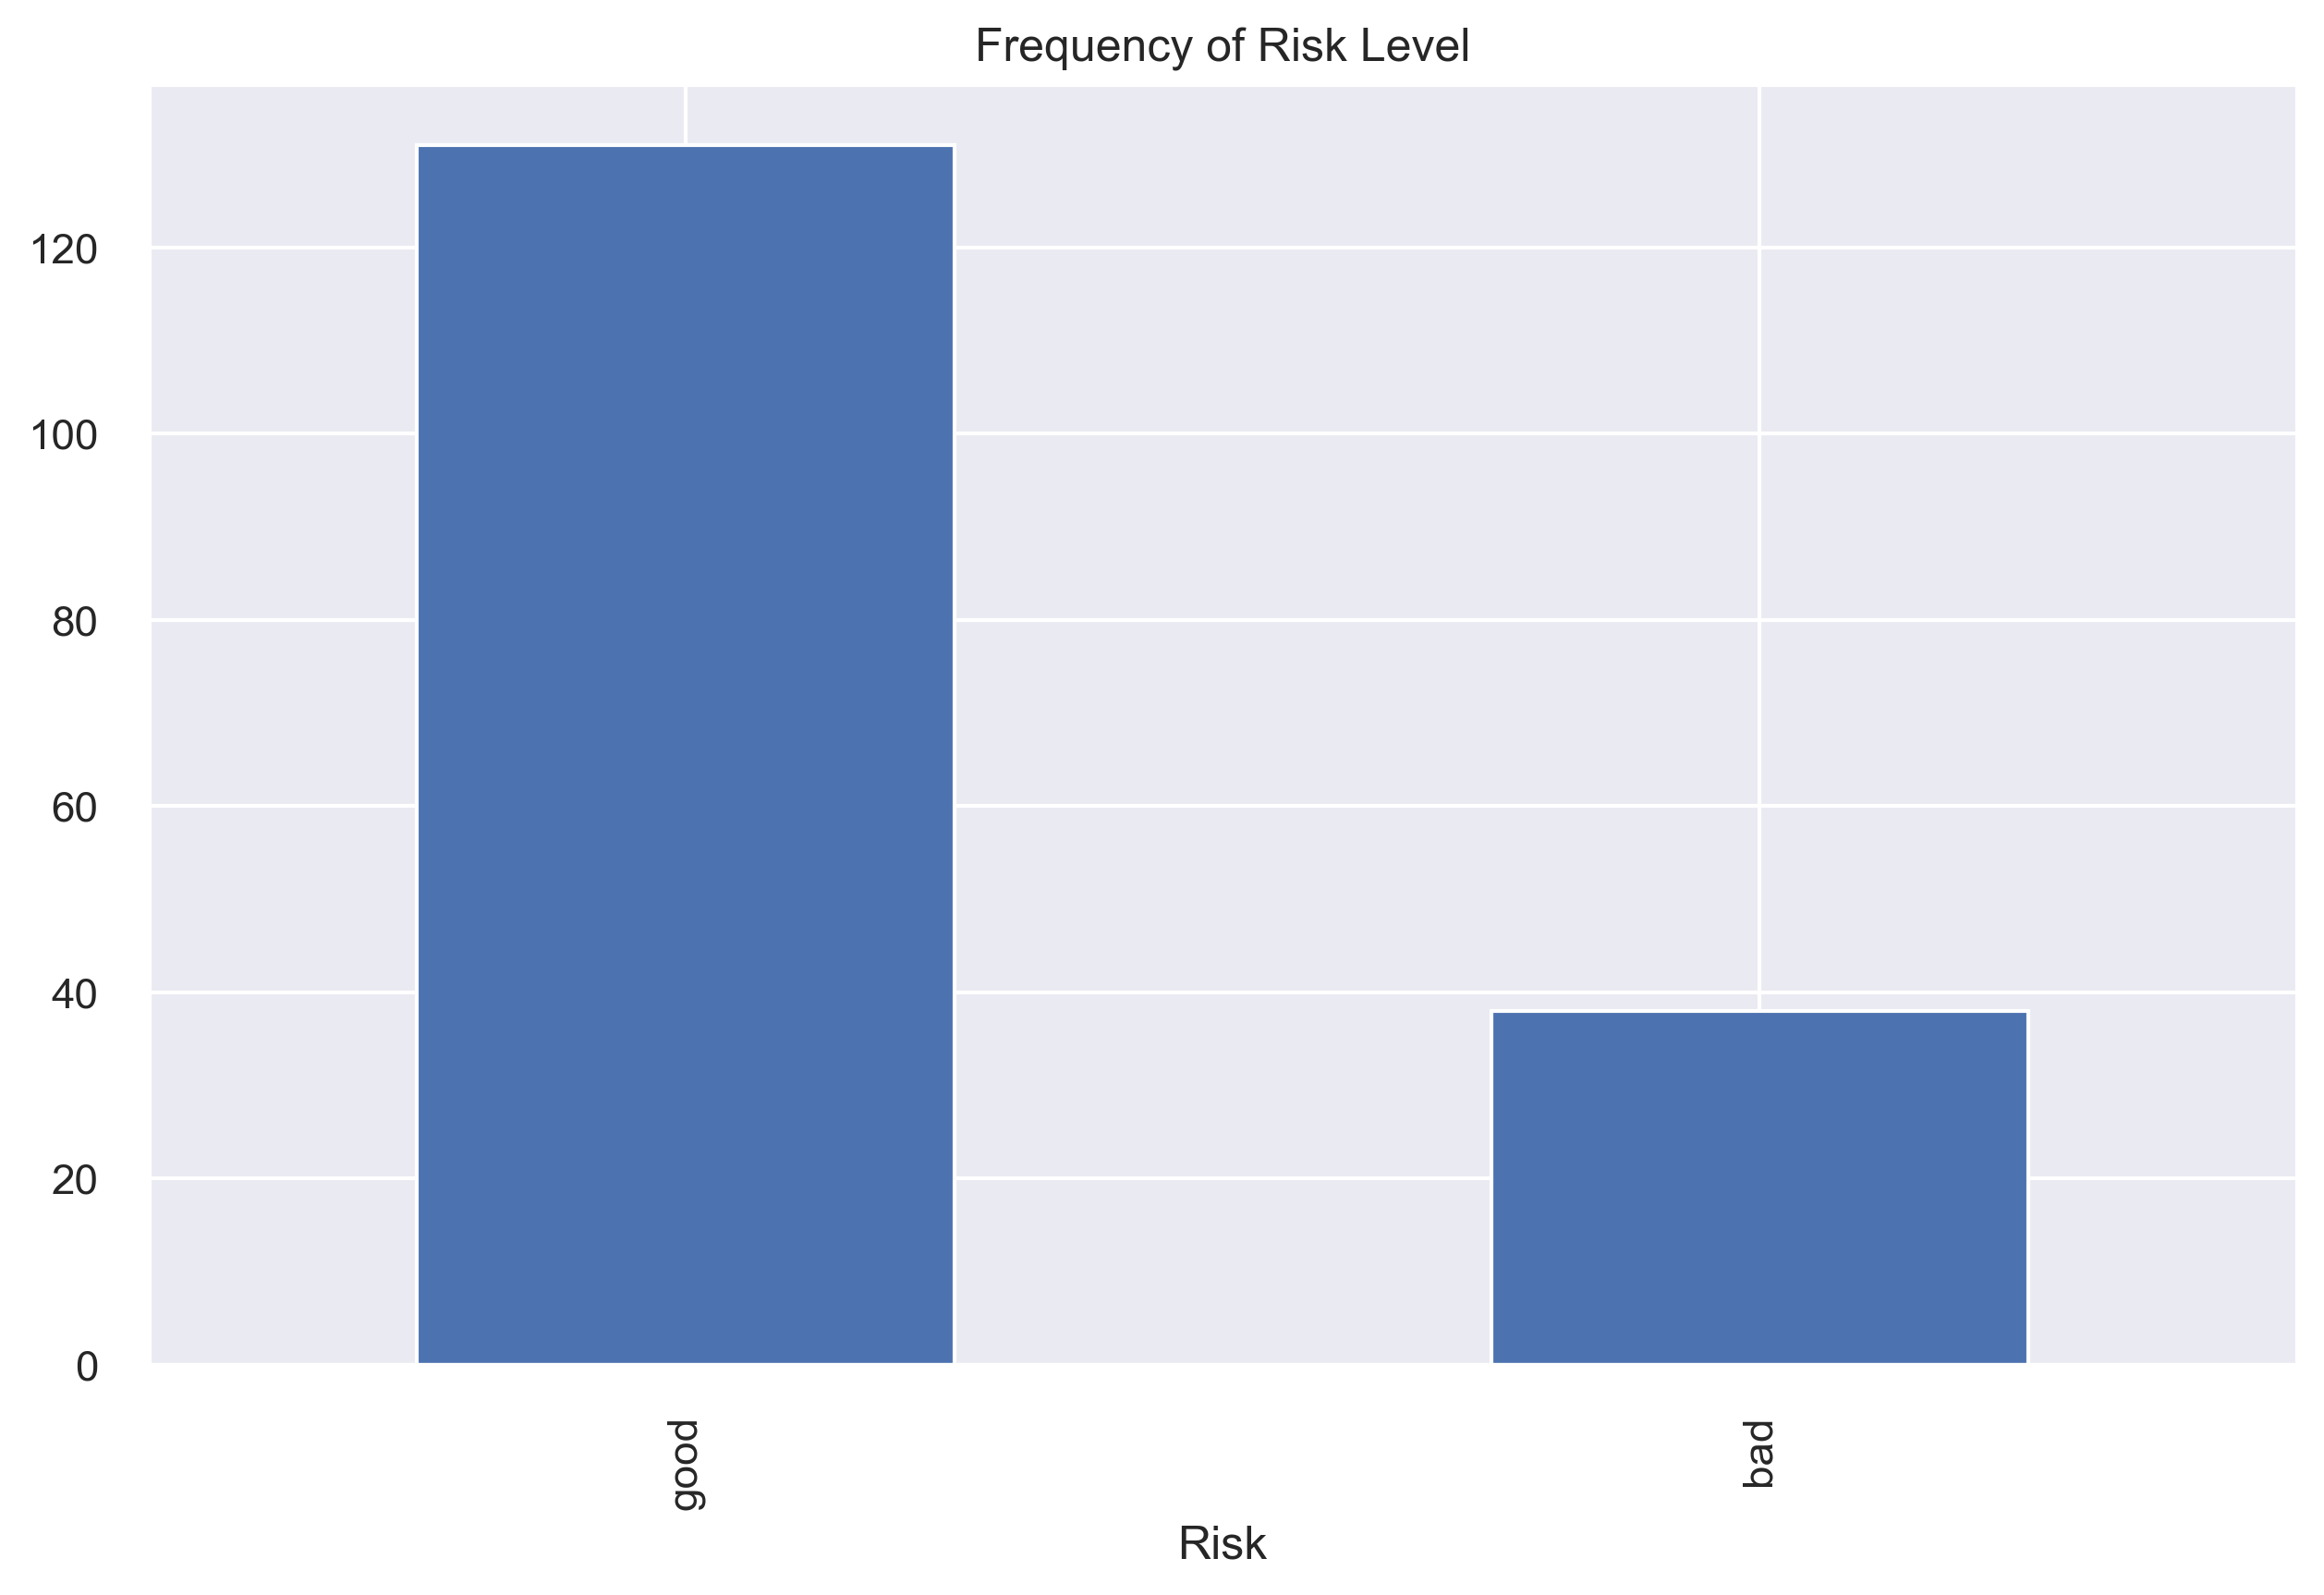

In [157]:
df_scaled[df_scaled.Clusters == 3]['Risk'].value_counts()\
                                    .plot(kind='bar',
                                    figsize=(10, 6),
                                    title="Frequency of Risk Level")
plt.show()

In [158]:
from sklearn.model_selection import train_test_split

In [159]:
df_scaled['Risk'] = df_scaled['Risk'].replace({'good': 1, 'bad': 0})

In [160]:
df_scaled.head()

,Age,Job,Credit amount,Duration,Clusters,Risk
0,2.766456,0.146949,-0.745131,-1.236478,3,1
1,-1.191404,0.146949,0.949817,2.248194,2,0
2,1.183312,-1.383771,-0.416562,-0.738668,0,1
3,0.831502,0.146949,1.634247,1.750384,2,1
4,1.535122,0.146949,0.566664,0.256953,3,0


In [161]:
X = df_scaled.drop('Risk', axis=1)
y = df_scaled.loc[:, ['Risk', 'Clusters']]

In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026)

In [163]:
first_cluster_train = X_train[X_train.Clusters == 0].iloc[:, :-1]
second_cluster_train = X_train[X_train.Clusters == 1].iloc[:, :-1]
third_cluster_train = X_train[X_train.Clusters == 2].iloc[:, :-1]
four_cluster_train = X_train[X_train.Clusters == 3].iloc[:, :-1]

## Logistic Regression for PD Estimation

In [164]:
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from imblearn.combine import SMOTEENN
import warnings
warnings.filterwarnings('ignore')

In [165]:
X_train1 = first_cluster_train
y_train1 = y_train[y_train.Clusters == 0]['Risk']
smote = SMOTEENN(random_state = 2026)
X_train1, y_train1 = smote.fit_resample(X_train1, y_train1.ravel())
logit = sm.Logit(y_train1, X_train1)
logit_fit1 = logit.fit()
print(logit_fit1.summary())

Optimization terminated successfully.
         Current function value: 0.256486
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  117
Model:                          Logit   Df Residuals:                      113
Method:                           MLE   Df Model:                            3
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.6173
Time:                        16:52:55   Log-Likelihood:                -30.009
converged:                       True   LL-Null:                       -78.407
Covariance Type:            nonrobust   LLR p-value:                 7.593e-21
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Age               2.0291      0.588      3.452      0.001       0.877       3.181
Job               0.

In [166]:
first_cluster_test = X_test[X_test.Clusters == 0].iloc[:, :-1]
second_cluster_test = X_test[X_test.Clusters == 1].iloc[:, :-1]
third_cluster_test = X_test[X_test.Clusters == 2].iloc[:, :-1]
four_cluster_test = X_test[X_test.Clusters == 3].iloc[:, :-1]

In [167]:
X_test1 = first_cluster_test
y_test1 = y_test[y_test.Clusters == 0]['Risk']
pred_prob1 = logit_fit1.predict(X_test1)

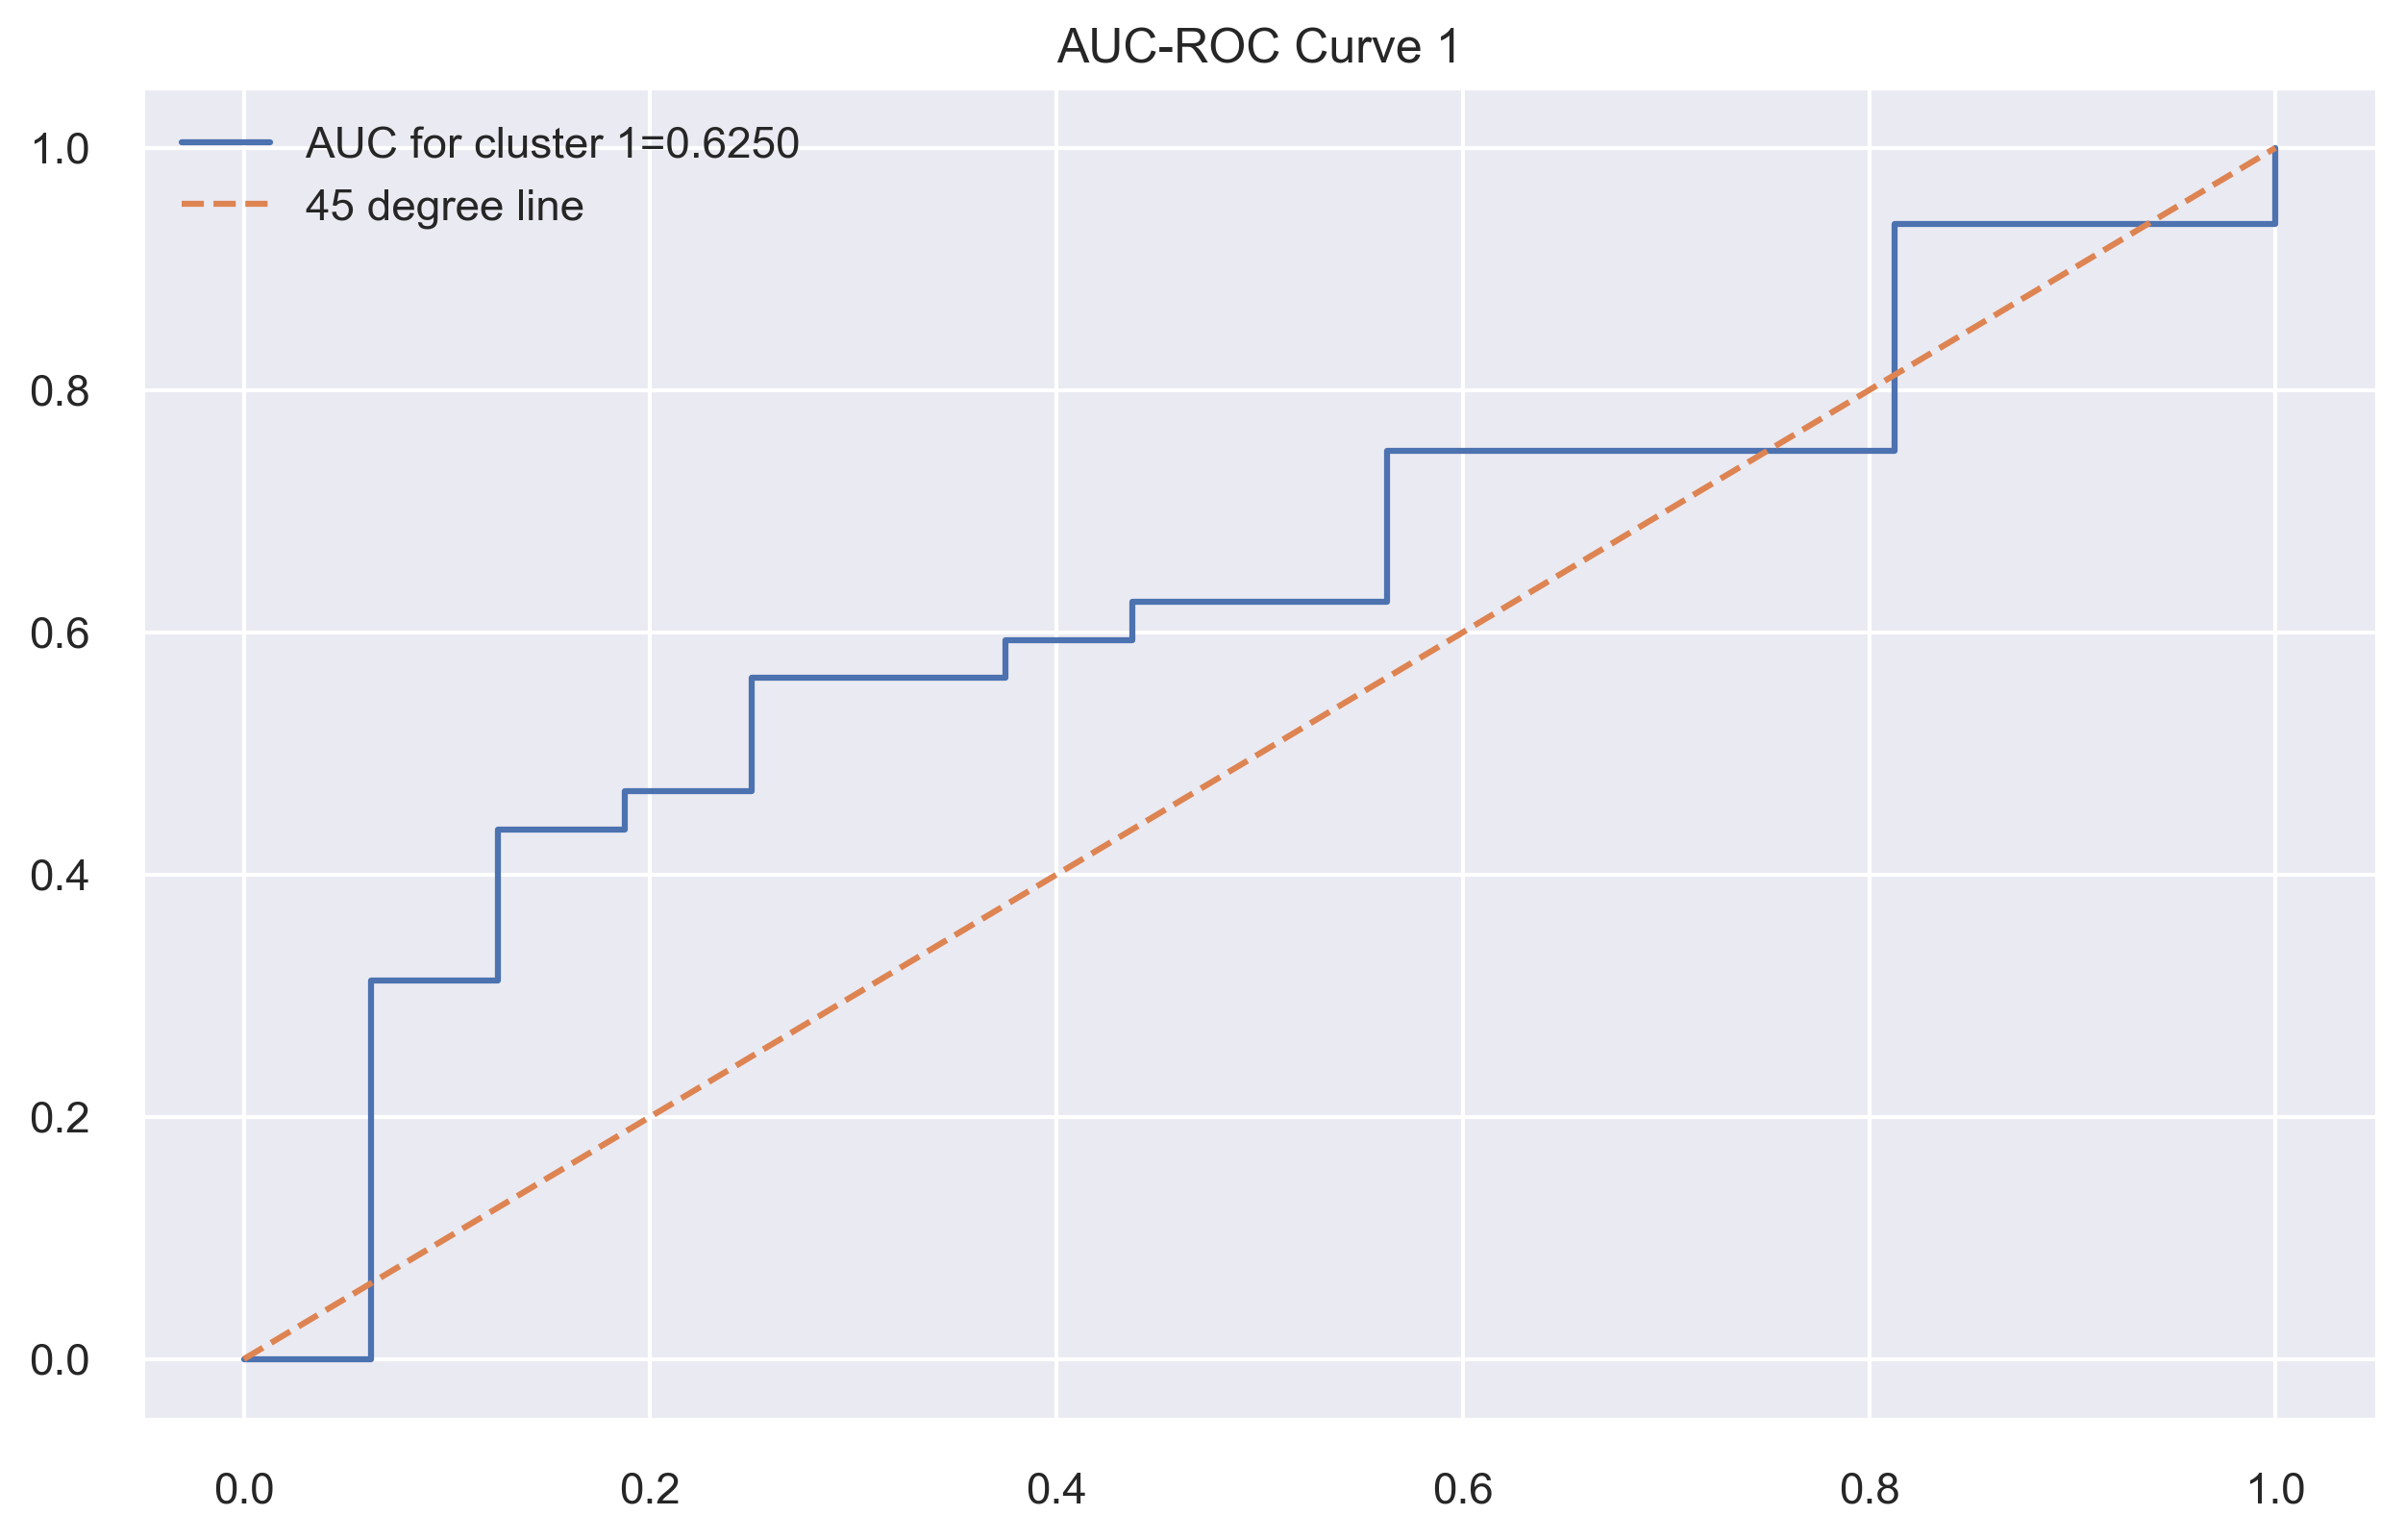

In [168]:
false_pos, true_pos, _ = roc_curve(y_test1.values,  pred_prob1)
auc = roc_auc_score(y_test1, pred_prob1)
plt.plot(false_pos,true_pos, label="AUC for cluster 1={:.4f} "
         .format(auc))
plt.plot([0, 1], [0, 1], linestyle = '--', label='45 degree line')
plt.legend(loc='best')
plt.title('AUC-ROC Curve 1')
plt.show()

In [169]:
X_train2 = second_cluster_train
y_train2 = y_train[y_train.Clusters == 1]['Risk']
smote = SMOTEENN(random_state = 2026)
X_train2, y_train2 = smote.fit_resample(X_train2, y_train2.ravel())
logit = sm.Logit(y_train2, X_train2)
logit_fit2 = logit.fit()
print(logit_fit2.summary())

Optimization terminated successfully.
         Current function value: 0.494062
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  217
Model:                          Logit   Df Residuals:                      213
Method:                           MLE   Df Model:                            3
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.2701
Time:                        16:52:55   Log-Likelihood:                -107.21
converged:                       True   LL-Null:                       -146.89
Covariance Type:            nonrobust   LLR p-value:                 4.219e-17
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Age               0.9058      0.297      3.049      0.002       0.323       1.488
Job               1.

In [170]:
X_test2 = second_cluster_test
y_test2 = y_test[y_test.Clusters == 1]['Risk']
pred_prob2 = logit_fit2.predict(X_test2)

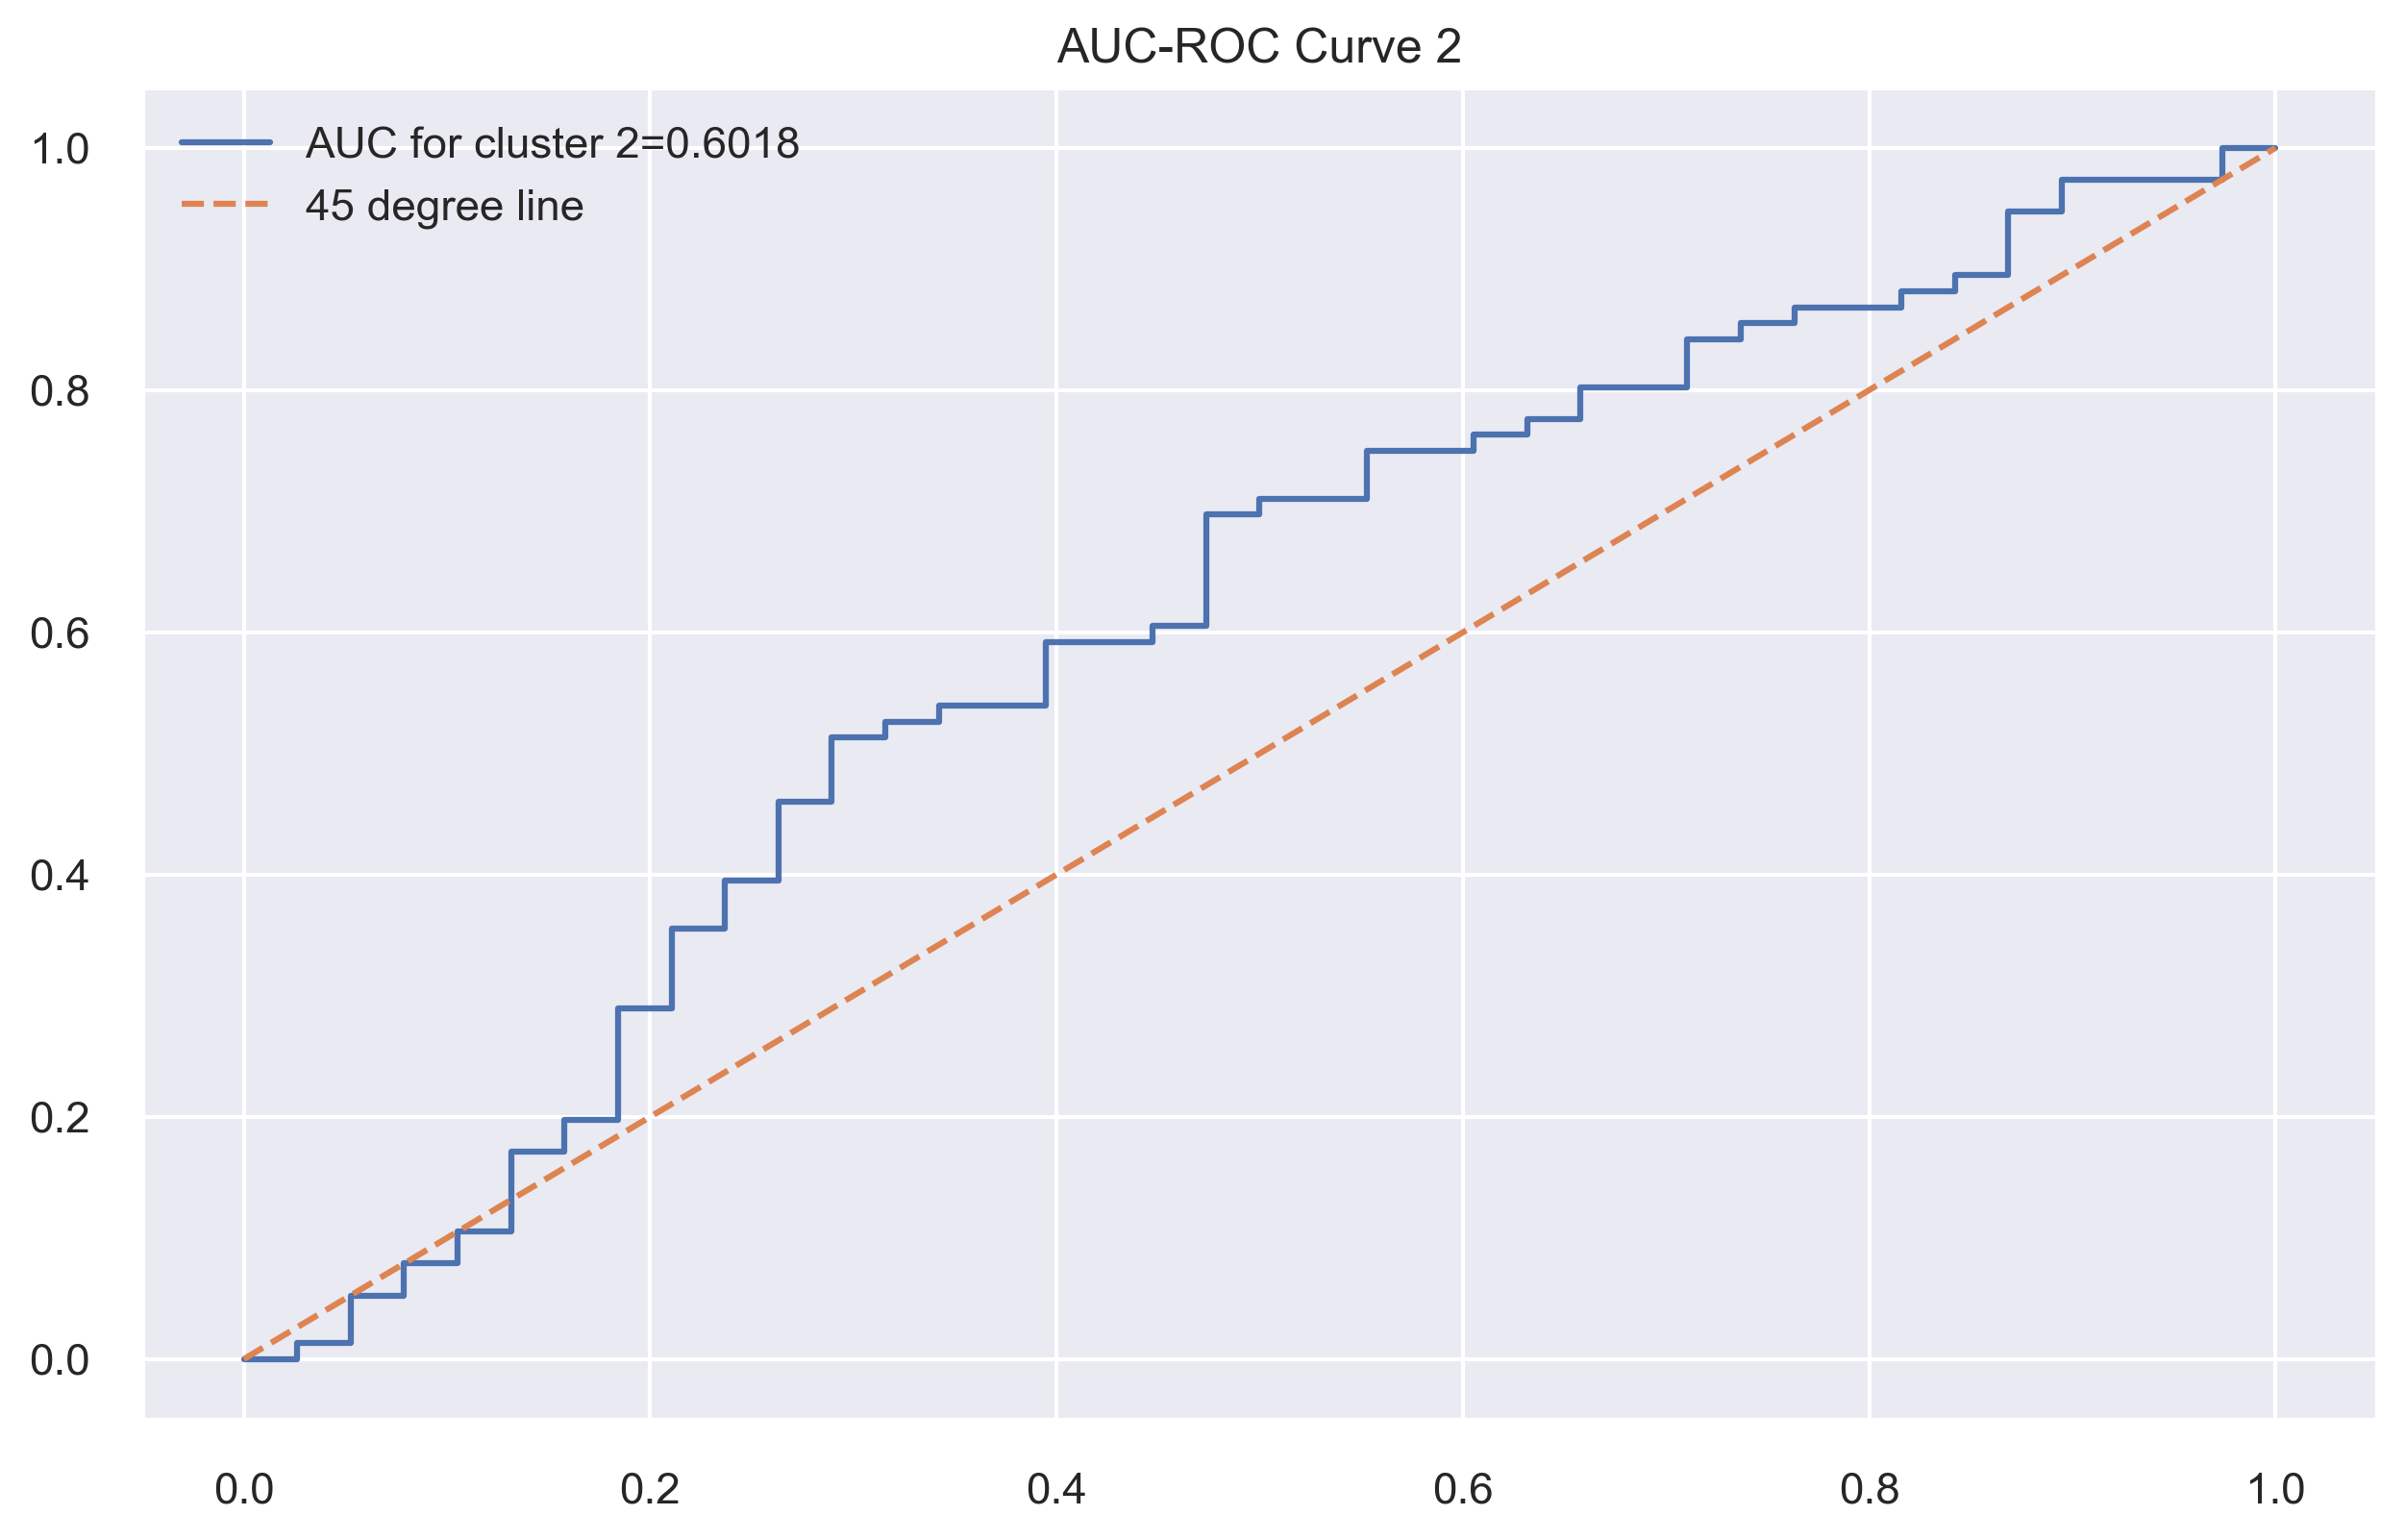

In [171]:
false_pos, true_pos, _ = roc_curve(y_test2.values,  pred_prob2)
auc = roc_auc_score(y_test2, pred_prob2)
plt.plot(false_pos,true_pos,label="AUC for cluster 2={:.4f} "
         .format(auc))
plt.plot([0, 1], [0, 1], linestyle = '--', label='45 degree line')
plt.legend(loc='best')
plt.title('AUC-ROC Curve 2')
plt.show()

In [172]:
X_train3 = third_cluster_train
y_train3 = y_train[y_train.Clusters == 2]['Risk']
smote = SMOTEENN(random_state = 2026)
X_train3, y_train3 = smote.fit_resample(X_train3, y_train3.ravel())
logit = sm.Logit(y_train3, X_train3)
logit_fit3 = logit.fit()
print(logit_fit3.summary())

Optimization terminated successfully.
         Current function value: 0.467695
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   28
Model:                          Logit   Df Residuals:                       24
Method:                           MLE   Df Model:                            3
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.2552
Time:                        16:52:55   Log-Likelihood:                -13.095
converged:                       True   LL-Null:                       -17.582
Covariance Type:            nonrobust   LLR p-value:                   0.02964
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Age              -1.2574      0.950     -1.324      0.186      -3.119       0.604
Job               2.

In [173]:
X_test3 = third_cluster_test
y_test3 = y_test[y_test.Clusters == 2]['Risk']
pred_prob3 = logit_fit3.predict(X_test3)

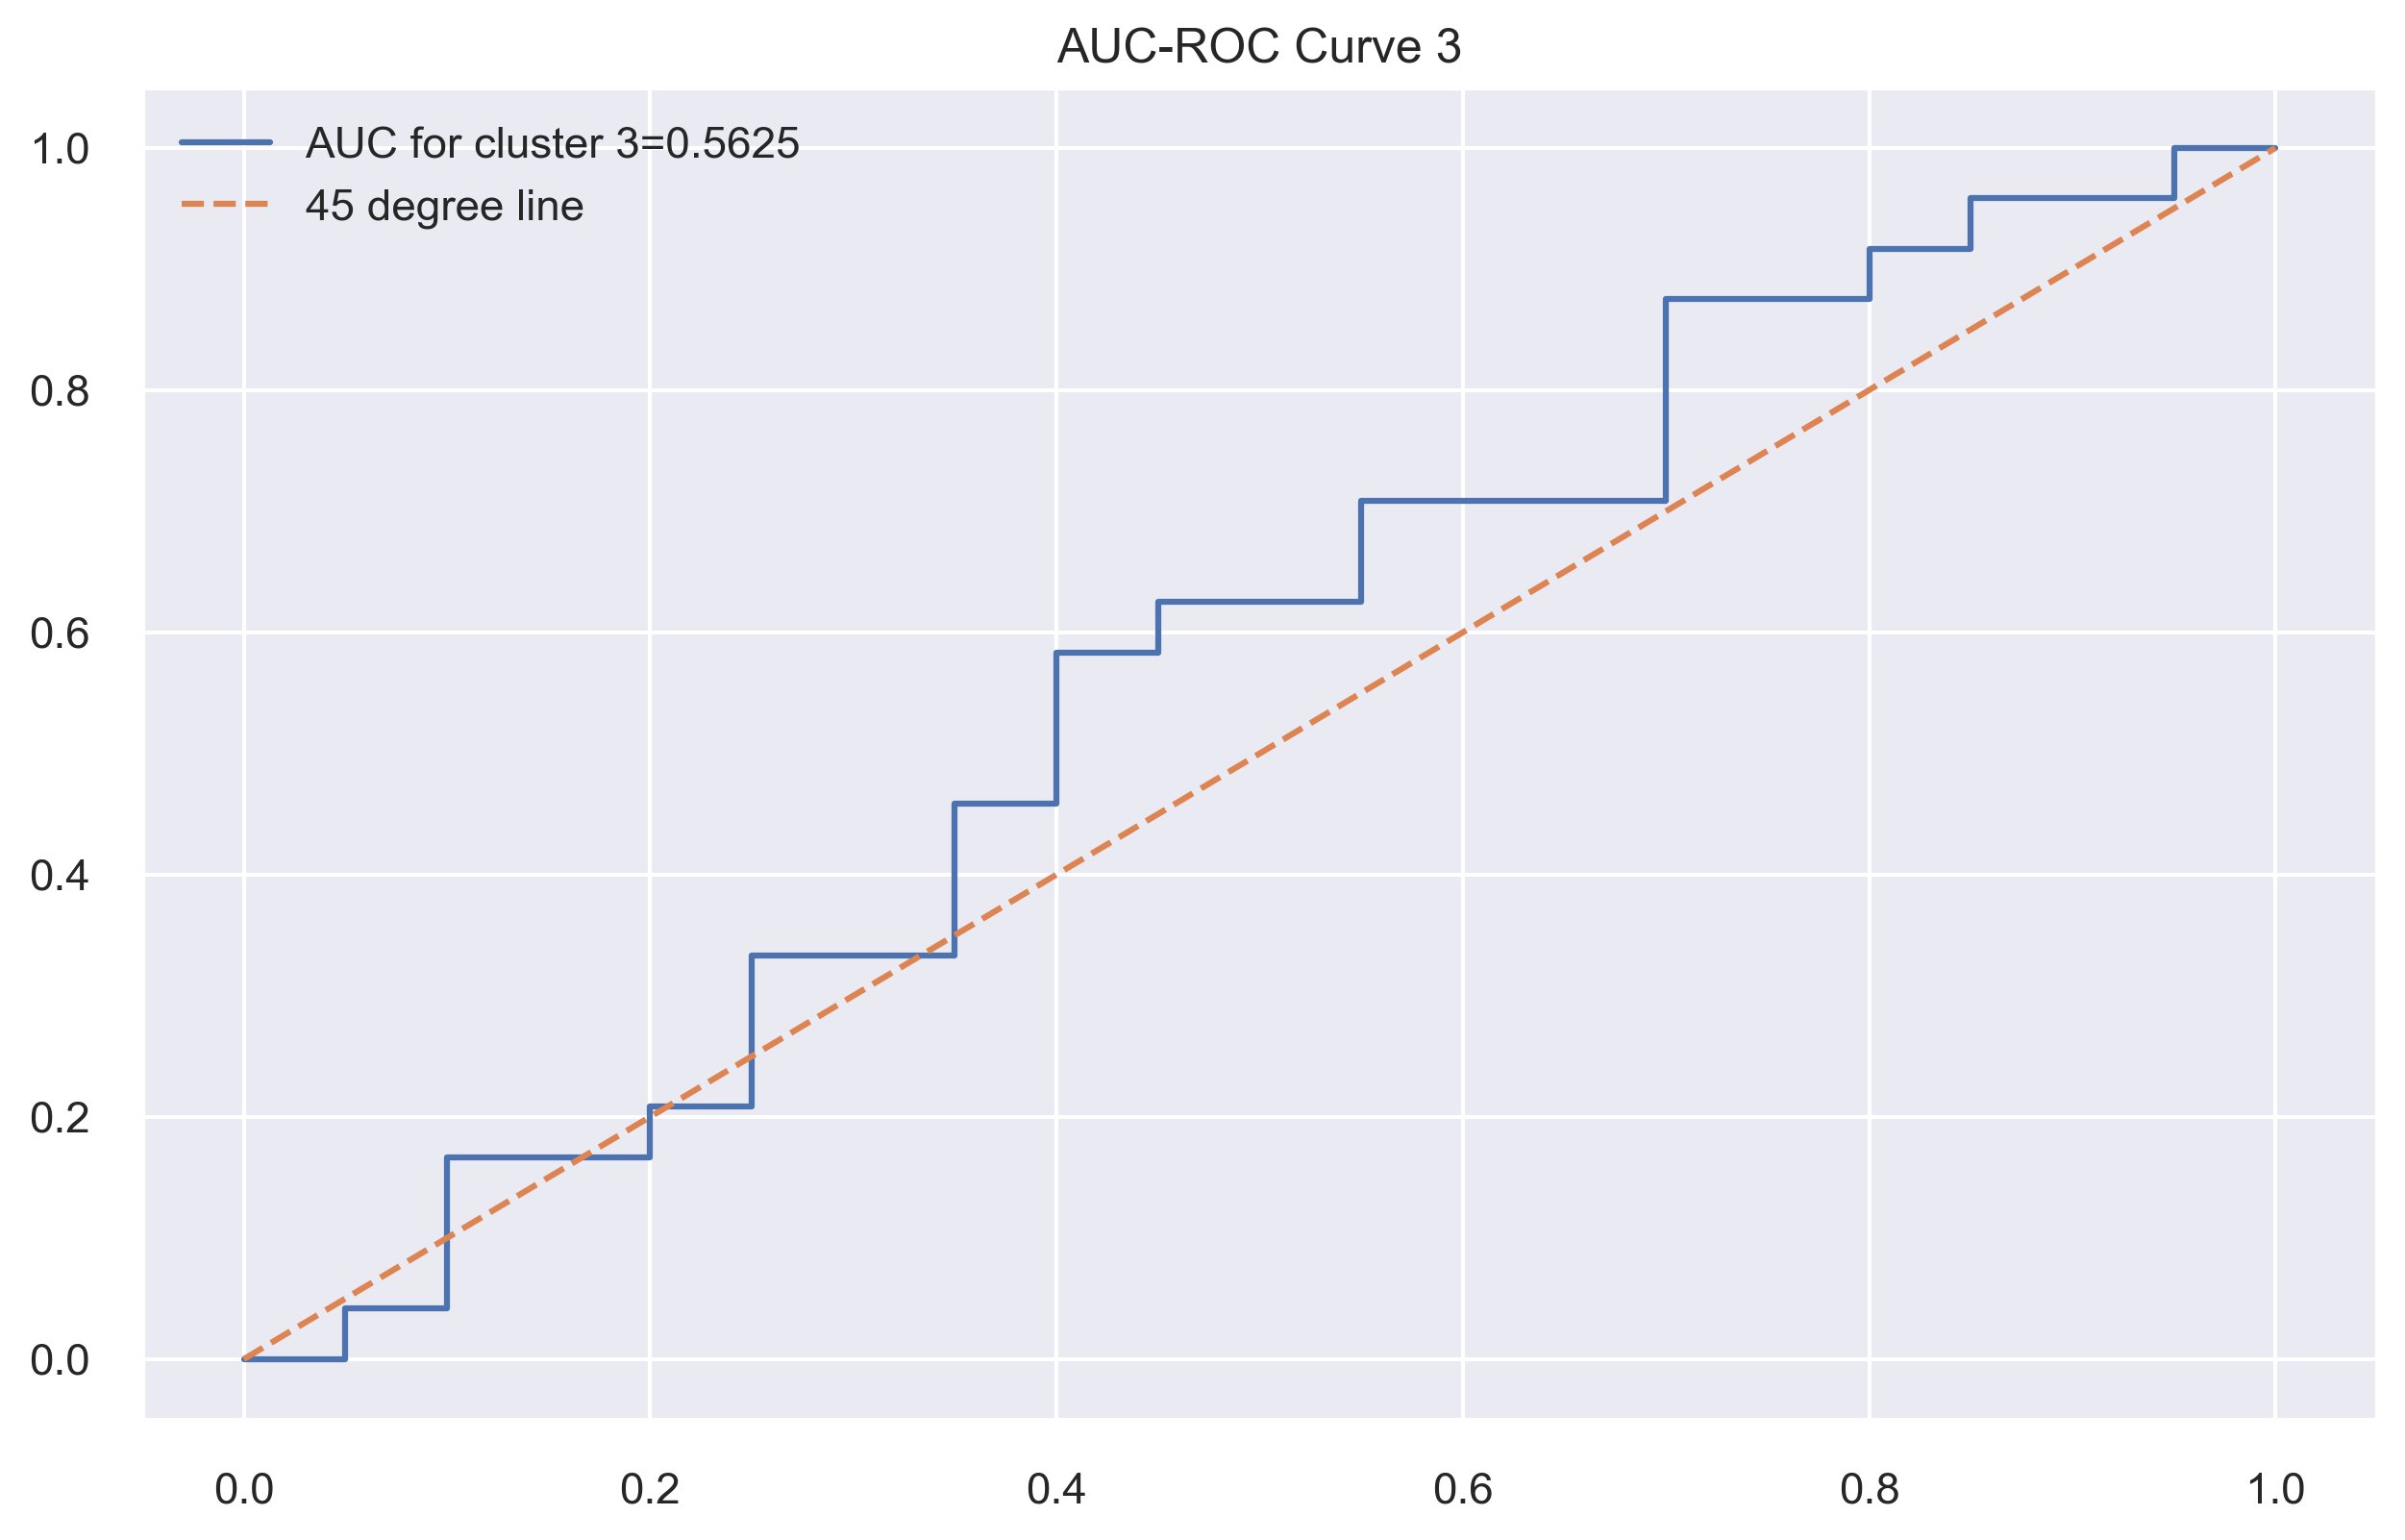

In [174]:
false_pos, true_pos, _ = roc_curve(y_test3.values,  pred_prob3)
auc = roc_auc_score(y_test3, pred_prob3)
plt.plot(false_pos,true_pos,label="AUC for cluster 3={:.4f} "
         .format(auc))
plt.plot([0, 1], [0, 1], linestyle = '--', label='45 degree line')
plt.legend(loc='best')
plt.title('AUC-ROC Curve 3')
plt.show()

In [175]:
X_train4 = four_cluster_train
y_train4 = y_train[y_train.Clusters == 3]['Risk']
smote = SMOTEENN(random_state = 2026)
X_train4, y_train4 = smote.fit_resample(X_train4, y_train4.ravel())
logit = sm.Logit(y_train4, X_train4)
logit_fit4 = logit.fit()
print(logit_fit4.summary())

Optimization terminated successfully.
         Current function value: 0.500670
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   85
Model:                          Logit   Df Residuals:                       81
Method:                           MLE   Df Model:                            3
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.2741
Time:                        16:52:55   Log-Likelihood:                -42.557
converged:                       True   LL-Null:                       -58.629
Covariance Type:            nonrobust   LLR p-value:                 4.880e-07
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Age              -0.1384      0.237     -0.584      0.559      -0.603       0.326
Job              -1.

In [176]:
X_test4 = four_cluster_test
y_test4 = y_test[y_test.Clusters == 3]['Risk']
pred_prob4 = logit_fit4.predict(X_test4)

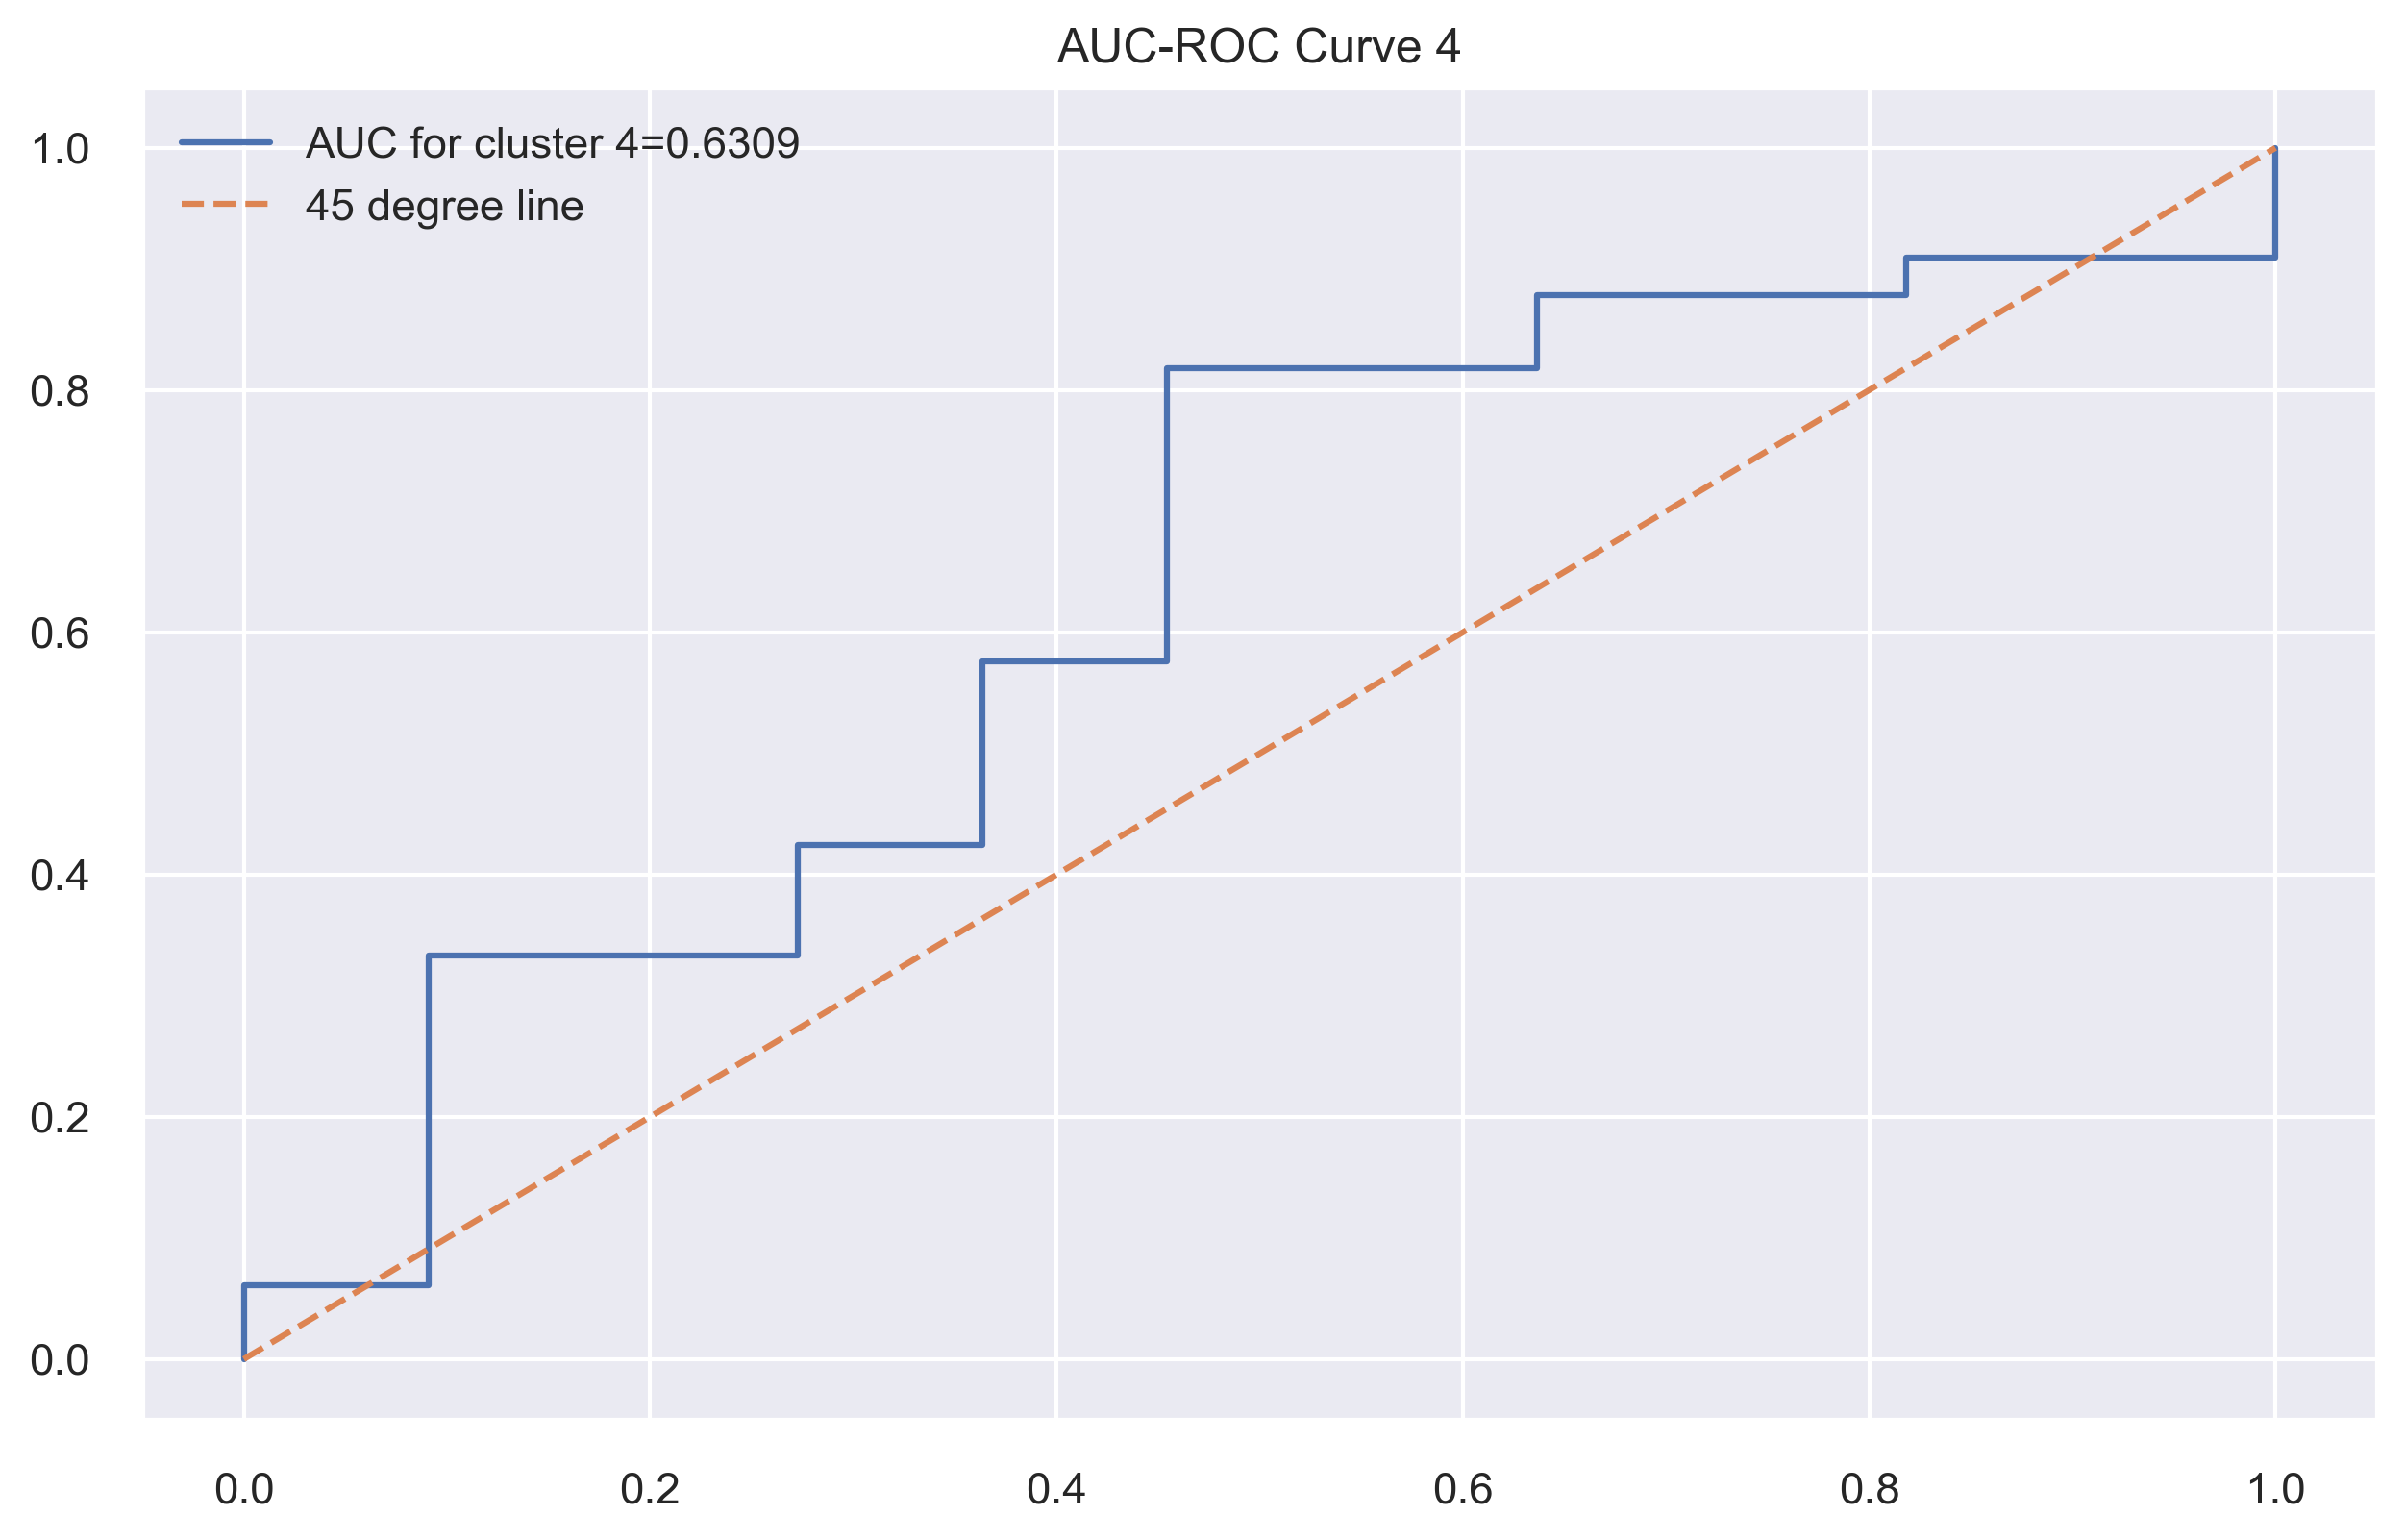

In [177]:
false_pos, true_pos, _ = roc_curve(y_test4.values,  pred_prob4)
auc = roc_auc_score(y_test4, pred_prob4)
plt.plot(false_pos,true_pos,label="AUC for cluster 4={:.4f} "
         .format(auc))
plt.plot([0, 1], [0, 1], linestyle = '--', label='45 degree line')
plt.legend(loc='best')
plt.title('AUC-ROC Curve 4')
plt.show()

## Bayesian Approach for PD Estimation

In [178]:
import pymc as pm 
import arviz as az

In [185]:
with pm.Model() as logistic_model1:
    beta_age = pm.Normal('coeff_age', mu=0, sigma=10)
    beta_job = pm.Normal('coeff_job', mu=0, sigma=10)
    beta_credit = pm.Normal('coeff_credit_amount', mu=0, sigma=10)
    beta_dur = pm.Normal('coeff_duration', mu=0, sigma=10)
    p = pm.Deterministic('p', pm.math.sigmoid(beta_age * 
                              X_train1['Age'] + beta_job *
                              X_train1['Job'] + beta_credit *
                              X_train1['Credit amount'] + beta_dur *
                              X_train1['Duration']))
with logistic_model1:
    observed = pm.Bernoulli("risk", p, observed=y_train1)
    map_estimate = pm.find_MAP()

Output()

In [180]:
param_list = ['coeff_age', 'coeff_job',
              'coeff_credit_amount', 'coeff_duration']
params = {}
for i in param_list:
    params[i] = [np.round(map_estimate[i], 6)] 
    
bayesian_params = pd.DataFrame.from_dict(params)    
print('The result of Bayesian estimation:\n {}'.format(bayesian_params))

The result of Bayesian estimation:
    coeff_age  coeff_job  coeff_credit_amount  coeff_duration
0    2.06982   4.695171                  0.0       -5.263878


In [ ]:
with pm.Model() as logistic_model2:
    beta_age = pm.Normal('coeff_age', mu=0, sigma=10)
    beta_job = pm.Normal('coeff_job', mu=0, sigma=10)
    beta_credit = pm.Normal('coeff_credit_amount', mu=0, sigma=10)
    beta_dur = pm.Normal('coeff_duration', mu=0, sigma=10)
    p = pm.Deterministic('p', pm.math.sigmoid(beta_age *
                              second_cluster_train['Age'] + 
                              beta_job * second_cluster_train['Job'] + 
                              beta_credit * second_cluster_train['Credit amount'] + 
                              beta_dur * second_cluster_train['Duration']))
with logistic_model2:
    observed = pm.Bernoulli("risk", p,
                            observed=y_train[y_train.Clusters == 1]
                            ['Risk'])
    map_estimate = pm.find_MAP()

Output()

In [182]:
param_list = [ 'coeff_age', 'coeff_job',
              'coeff_credit_amount', 'coeff_duration']
params = {}
for i in param_list:
    params[i] = [np.round(map_estimate[i], 6)]
    
bayesian_params = pd.DataFrame.from_dict(params)    
print('The result of Bayesian estimation:\n {}'.format(bayesian_params))

The result of Bayesian estimation:
    coeff_age  coeff_job  coeff_credit_amount  coeff_duration
0    -0.7649        0.0            -0.297713        -0.52946


## Markov Chain for PD Estimation

In [183]:
import logging
logger = logging.getLogger('pymc')
logger.setLevel(logging.ERROR)

In [184]:
with logistic_model1:
    trace = pm.sample(2000, chains=2, tune=1000, progressbar=True)
az.plot_trace(trace)
plt.show()

Output()

ValueError: Not enough samples to build a trace.

In [ ]:
with logistic_model1:
    display(az.summary(trace, round_to=6)[:4])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
coeff_age,1.496475,0.172981,1.168816,1.814293,0.002949,0.002709,3467.798073,2596.587027,1.000185
coeff_job,-0.103842,0.161896,-0.380198,0.225043,0.002770,0.002467,3418.530672,2913.999697,1.000278
coeff_credit_amount,1.905649,0.339603,1.263989,2.542934,0.006437,0.005237,2789.802577,2634.946719,1.000955
coeff_duration,-1.665788,0.285914,-2.197140,-1.113592,0.005453,0.004554,2759.136165,2885.683917,1.000966


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [coeff_age, coeff_job, coeff_credit_amount, coeff_duration]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 374 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


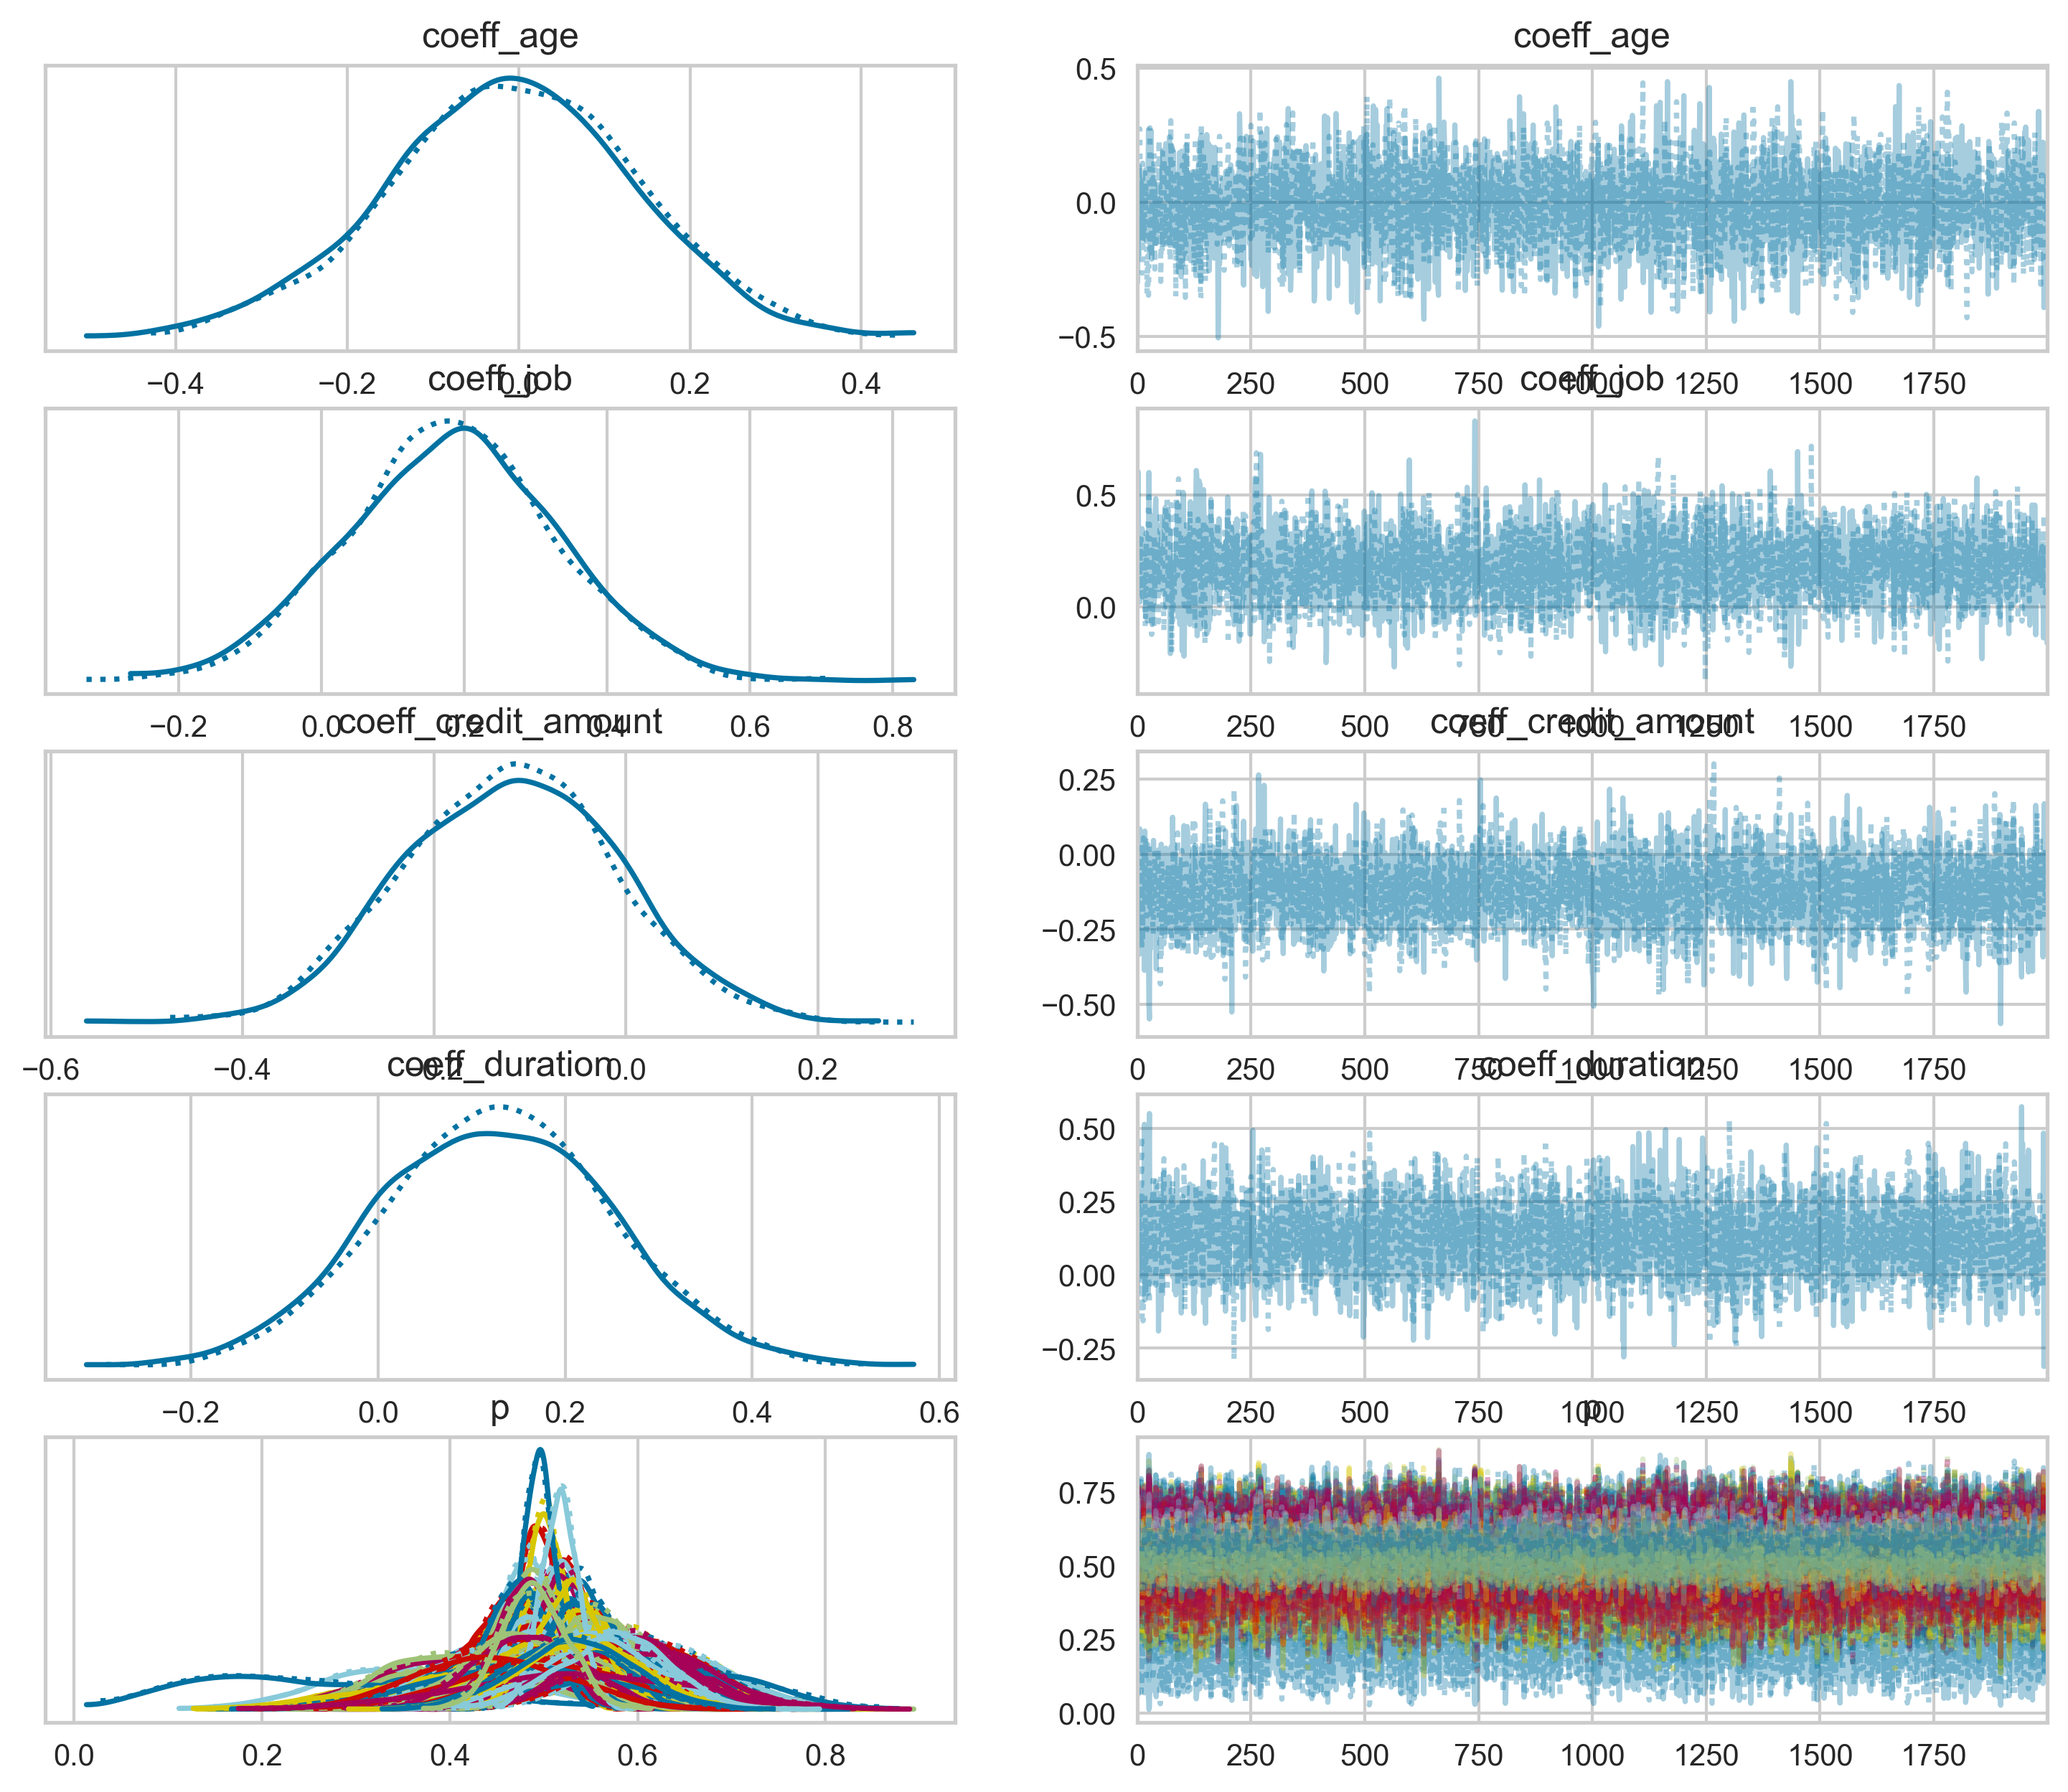

In [ ]:
with logistic_model2:
    trace = pm.sample(2000, chains=2, tune=1000, progressbar=True)
az.plot_trace(trace)
plt.show()

In [ ]:
with logistic_model2:
    display(az.summary(trace, round_to=6)[:4])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
coeff_age,-0.009551,0.144885,-0.293171,0.253694,0.002396,0.002117,3663.827725,2878.472857,1.000545
coeff_job,0.181677,0.147513,-0.095545,0.457955,0.002564,0.002264,3314.259387,3195.725846,1.000819
coeff_credit_amount,-0.121288,0.113395,-0.338613,0.079954,0.002275,0.001735,2499.709792,2522.856871,1.000634
coeff_duration,0.125716,0.124143,-0.098798,0.363603,0.002568,0.001774,2331.654402,2490.835293,1.001674


## SVC for PD Estimation

In [ ]:
from sklearn.svm import SVC
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
import time

In [ ]:
param_svc = {'gamma': [1e-6, 1e-2],
             'C':[0.001,.09,1,5,10],
             'kernel':('linear','rbf')}

In [ ]:
svc = SVC(class_weight='balanced')
halve_SVC = HalvingRandomSearchCV(svc, param_svc, 
                                  scoring = 'roc_auc', n_jobs=-1)
halve_SVC.fit(X_train1, y_train1)
print('Best hyperparameters for first cluster in SVC {} with {}'.
      format(halve_SVC.best_score_, halve_SVC.best_params_))

Best hyperparameters for first cluster in SVC 0.8673412347395099 with {'kernel': 'linear', 'gamma': 1e-06, 'C': 5}


In [ ]:
y_pred_SVC1 = halve_SVC.predict(X_test1)
print('The ROC AUC score of SVC for first cluster is {:.4f}'.
      format(roc_auc_score(y_test1, y_pred_SVC1)))

The ROC AUC score of SVC for first cluster is 0.5354


In [ ]:
halve_SVC.fit(X_train2, y_train2)
print('Best hyperparameters for second cluster in SVC {} with {}'.
      format(halve_SVC.best_score_, halve_SVC.best_params_))

Best hyperparameters for second cluster in SVC 0.5185875679263081 with {'kernel': 'rbf', 'gamma': 0.01, 'C': 5}


In [ ]:
y_pred_SVC2 = halve_SVC.predict(X_test2)
print('The ROC AUC score of SVC for first cluster is {:.4f}'.
      format(roc_auc_score(y_test2, y_pred_SVC2)))

The ROC AUC score of SVC for first cluster is 0.5368


## RF for PD Estimation

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(random_state=42)

In [ ]:
param_rfc = {'n_estimators': [100, 300],
    'criterion' :['gini', 'entropy'],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [3, 4, 5, 6],
    'min_samples_split':[5, 10]}

In [ ]:
halve_RF = HalvingRandomSearchCV(rfc, param_rfc,
                                 scoring = 'roc_auc', n_jobs=-1)
halve_RF.fit(X_train1, y_train1)
print('Best hyperparameters for first cluster in RF {} with {}'.
      format(halve_RF.best_score_, halve_RF.best_params_))

Best hyperparameters for first cluster in RF 0.9474598930481284 with {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 5, 'criterion': 'gini'}


In [ ]:
y_pred_RF1 = halve_RF.predict(X_test1)
print('The ROC AUC score of RF for first cluster is {:.4f}'.
      format(roc_auc_score(y_test1, y_pred_RF1)))

The ROC AUC score of RF for first cluster is 0.5394


In [ ]:
halve_RF.fit(X_train2, y_train2)
print('Best hyperparameters for second cluster in RF {} with {}'.
      format(halve_RF.best_score_, halve_RF.best_params_))

Best hyperparameters for second cluster in RF 0.7011733880154933 with {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 6, 'criterion': 'entropy'}


In [ ]:
y_pred_RF2 = halve_RF.predict(X_test2)
print('The ROC AUC score of RF for first cluster is {:.4f}'.
      format(roc_auc_score(y_test2, y_pred_RF2)))

The ROC AUC score of RF for first cluster is 0.5342


## NN for PD Estimation

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
param_NN = {"hidden_layer_sizes": [(100, 50), (50, 50), (10, 100)],
            "solver": ["lbfgs", "sgd", "adam"], 
            "learning_rate_init": [0.001, 0.05]}

In [ ]:
MLP = MLPClassifier(random_state=42)

In [ ]:
param_halve_NN = HalvingRandomSearchCV(MLP, param_NN,
                                       scoring = 'roc_auc')
param_halve_NN.fit(X_train1, y_train1)
print('Best hyperparameters for first cluster in NN are {}'.
      format(param_halve_NN.best_params_))

Best hyperparameters for first cluster in NN are {'solver': 'sgd', 'learning_rate_init': 0.05, 'hidden_layer_sizes': (10, 100)}


In [ ]:
y_pred_NN1 = param_halve_NN.predict(X_test1)
print('The ROC AUC score of NN for first cluster is {:.4f}'.
      format(roc_auc_score(y_test1, y_pred_NN1)))

The ROC AUC score of NN for first cluster is 0.5645


In [ ]:
param_halve_NN.fit(X_train2, y_train2)
print('Best hyperparameters for first cluster in NN are {}'.
      format(param_halve_NN.best_params_))

Best hyperparameters for first cluster in NN are {'solver': 'lbfgs', 'learning_rate_init': 0.001, 'hidden_layer_sizes': (10, 100)}


In [ ]:
y_pred_NN2 = param_halve_NN.predict(X_test2)
print('The ROC AUC score of NN for first cluster is {:.4f}'.
      format(roc_auc_score(y_test2, y_pred_NN2)))

The ROC AUC score of NN for first cluster is 0.5605


## DL for PD Estimation

In [ ]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ------------------------------- 74.7/351.2 MB 35.3 kB/s eta 2:10:37
   -------- ----------------------------

In [ ]:
!pip install scikeras

In [ ]:
from tensorflow import keras
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
import logging
tf.get_logger().setLevel(logging.ERROR)

In [ ]:
def DL_risk(dropout_rate,verbose=0):
    model = keras.Sequential()
    model.add(Dense(128,kernel_initializer='normal', 
        activation = 'relu', input_dim=4))
    model.add(Dense(64, kernel_initializer='normal', 
        activation = 'relu'))
    model.add(Dense(8,kernel_initializer='normal', 
        activation = 'relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(loss='binary_crossentropy', optimizer='rmsprop')
    return model

In [ ]:
parameters = {'batch_size':  [10, 50, 100],
          'epochs':  [50, 100, 150],
             'dropout_rate':[0.2, 0.4]}
model = KerasClassifier(model = DL_risk, dropout_rate=0.2, verbose=0)
gs = GridSearchCV(estimator = model,
                       param_grid = parameters,
                          scoring = 'roc_auc',
                          cv= 3)

In [ ]:
gs.fit(X_train1, y_train1, verbose=0)
print('Best hyperparameters for first cluster in DL are {}'.
      format(gs.best_params_))

Best hyperparameters for first cluster in DL are {'batch_size': 10, 'dropout_rate': 0.2, 'epochs': 50}


In [ ]:
model = KerasClassifier(model= DL_risk,
                        dropout_rate = gs.best_params_['dropout_rate'],
                        verbose = 0,
                        batch_size = gs.best_params_['batch_size'],
                        epochs = gs.best_params_['epochs'])
model.fit(X_train1, y_train1)
DL_predict1 = model.predict(X_test1)
DL_ROC_AUC = roc_auc_score(y_test1, pd.DataFrame(DL_predict1.flatten()))
print('DL_ROC_AUC is {:.4f}'.format(DL_ROC_AUC))

DL_ROC_AUC is 0.5851


In [ ]:
gs.fit(X_train2.values, y_train2.values, verbose=0)
print('Best parameters for second cluster in DL are {}'.
      format(gs.best_params_))

Best parameters for second cluster in DL are {'batch_size': 10, 'dropout_rate': 0.2, 'epochs': 50}


In [ ]:
model = KerasClassifier(build_fn = DL_risk,
                        dropout_rate= gs.best_params_['dropout_rate'],
                        verbose = 0,
                        batch_size = gs.best_params_['batch_size'],
                        epochs = gs.best_params_['epochs'])
model.fit(X_train2, y_train2)
DL_predict2 =  model.predict(X_test2)
DL_ROC_AUC = roc_auc_score(y_test2, DL_predict2.flatten()) 
print('DL_ROC_AUC is {:.4f}'.format(DL_ROC_AUC))

DL_ROC_AUC is 0.6395
